# Avance 1. Análisis exploratorio de datos

**Equipo 51** · Proyecto Integrador, Maestría en Inteligencia Artificial Aplicada (MNA)
**Proyecto:** AI Co-Pilot Video-to-SOP (patrocinador: Alignity)

**Objetivos de aprendizaje**

- **2.1** Elegir las características más relevantes para reducir la dimensionalidad y aumentar la capacidad de generalización del modelo.
- **2.2** Abordar y corregir los problemas identificados en los datos.

## Contexto

El proyecto busca convertir videos de procedimientos (operadores realizando una tarea) en un SOP (*Standard Operating Procedure*) estructurado, trazable a evidencia en video y revisado por un humano. Para el sistema, la unidad de información central no es el píxel sino el **paso del procedimiento**: cuándo empieza, cuándo termina, qué acción es y si se ejecutó correctamente.

Siguiendo la regla de datos del brief (Fase 1: solo datasets públicos; ningún material del cliente en el repositorio), este EDA se realiza sobre las **anotaciones de CaptainCook4D** (Peddi et al., NeurIPS 2024 Datasets & Benchmarks), un dataset de 384 grabaciones egocéntricas de 24 recetas en las que los participantes siguen un procedimiento y, en parte de las grabaciones, cometen errores intencionales. Es el dataset del brief destinado a medir la detección de desviaciones procedurales.

**¿Por qué analizar anotaciones y no los videos?** Las anotaciones son la *verdad de referencia* contra la que se medirá el sistema (segmentación de pasos, orden y detección de errores). Entender su estructura, sus sesgos y sus problemas de calidad es requisito antes de entrenar o evaluar cualquier componente. El análisis de los fotogramas en sí corresponde a la capa de percepción (V-JEPA 2) en la Semana 3.

**Marco metodológico.** Esta libreta corresponde a las fases *Data Understanding* y *Data Preparation* de CRISP-ML(Q) (Studer et al., 2021), cuyo aseguramiento de calidad pide documentar la calidad de los datos, justificar cada transformación y evitar la fuga de información entre particiones.

**Licencia de los datos:** repositorio `CaptainCook4D/annotations`, licencia MIT. Los archivos se descargan en tiempo de ejecución desde un *commit* fijo y **no se versionan en el repositorio del equipo**.

> **Nota de ejecución:** la libreta debe correrse de principio a fin de forma secuencial (*Kernel → Restart & Run All*). Requiere conexión a internet la primera vez para descargar ~5 MB de anotaciones.

## 1. Configuración del entorno

Dependencias: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn`. Se fija una semilla para que cualquier resultado aleatorio sea reproducible.

In [62]:
# Si falta alguna dependencia, descomentar la siguiente línea:
# %pip install "pandas>=2.0" numpy matplotlib "seaborn>=0.13" scipy scikit-learn

import json
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 51
np.random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

import sklearn, scipy, matplotlib
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__,
      "| scipy", scipy.__version__, "| sklearn", sklearn.__version__, "| matplotlib", matplotlib.__version__)

pandas 3.0.6 | numpy 2.4.6 | seaborn 0.13.2 | scipy 1.17.1 | sklearn 1.9.1 | matplotlib 3.11.2


## 2. Carga de datos

Se descargan cuatro archivos del repositorio oficial de anotaciones, fijados a un *commit* específico para que el análisis sea reproducible aunque el repositorio cambie:

| Archivo | Contenido |
|---|---|
| `complete_step_annotations.json` | Por grabación: actividad, persona, entorno y la lista de pasos con inicio, fin, descripción y bandera de error. |
| `error_annotations.json` | Por paso: lista de errores con su categoría (*tag*) y descripción libre. |
| `video_information.csv` | Metadatos de cada video: duración, entorno y persona. |
| `recordings_data_split_combined.json` | Partición oficial train / val / test por grabación. |

Los archivos se guardan en `data/raw/captaincook4d/`, carpeta que debe estar en `.gitignore`.

In [63]:
COMMIT = "a8a920a3293c4db27099a20ddbe3a3a9be1283e3"
BASE_URL = f"https://raw.githubusercontent.com/CaptainCook4D/annotations/{COMMIT}"
RAW_DIR = Path("data/raw/captaincook4d")
RAW_DIR.mkdir(parents=True, exist_ok=True)

FILES = [
    "annotation_json/complete_step_annotations.json",
    "annotation_json/error_annotations.json",
    "metadata/video_information.csv",
    "data_splits/recordings_data_split_combined.json",
]

def fetch(rel_path: str) -> Path:
    # Descarga un archivo una sola vez y lo reutiliza desde la caché local.
    dest = RAW_DIR / Path(rel_path).name
    if not dest.exists():
        urllib.request.urlretrieve(f"{BASE_URL}/{rel_path}", dest)
    return dest

paths = {Path(f).stem: fetch(f) for f in FILES}
for name, p in paths.items():
    print(f"{name:40s} {p.stat().st_size/1024:8.1f} KB")

complete = json.loads(paths["complete_step_annotations"].read_text())
errors_raw = json.loads(paths["error_annotations"].read_text())
video_info = pd.read_csv(paths["video_information"])
splits = json.loads(paths["recordings_data_split_combined"].read_text())

print("\nGrabaciones en anotaciones de pasos:", len(complete))
print("Grabaciones en anotaciones de error:", len(errors_raw))
print("Filas en metadatos de video:", len(video_info))

complete_step_annotations                  1561.7 KB
error_annotations                          1984.1 KB
video_information                             8.5 KB
recordings_data_split_combined                3.2 KB

Grabaciones en anotaciones de pasos: 384
Grabaciones en anotaciones de error: 384
Filas en metadatos de video: 384


## 3. Construcción de las tablas de análisis

Los JSON son jerárquicos (grabación → pasos → errores). Para el EDA se aplanan en dos niveles de granularidad, porque las preguntas del proyecto viven en ambos:

- **Nivel paso** (`steps`): una fila por paso anotado. Es la unidad que el sistema tiene que segmentar, ordenar y validar.
- **Nivel grabación** (`recs`): una fila por video, con agregados de sus pasos. Es la unidad que el sistema recibe como entrada.

Ambas fuentes de anotación vienen en el mismo orden por grabación; se verifica explícitamente antes de unirlas por posición (un `step_id` puede repetirse dentro de una misma grabación, así que no sirve como llave por sí solo).

In [64]:
# --- Nivel paso: anotaciones de pasos ---
step_rows = []
for rec_id, rec in complete.items():
    for order, s in enumerate(rec["steps"]):
        step_rows.append({
            "recording_id": rec_id,
            "activity_id": rec["activity_id"],
            "activity_name": rec["activity_name"],
            "person_id": rec["person_id"],
            "environment": rec["environment"],
            "step_order": order,
            "step_id": s["step_id"],
            "description": s["description"],
            "start_time": s["start_time"],
            "end_time": s["end_time"],
            "has_errors": s["has_errors"],
        })
steps = pd.DataFrame(step_rows)

# --- Nivel paso: anotaciones de error (misma secuencia) ---
err_by_rec = {r["recording_id"]: r for r in errors_raw}
err_rows, misaligned = [], 0
for rec_id, rec in complete.items():
    e_steps = err_by_rec[rec_id]["step_annotations"]
    if len(e_steps) != len(rec["steps"]):
        misaligned += 1
    for order, (s, e) in enumerate(zip(rec["steps"], e_steps)):
        if s["step_id"] != e["step_id"] or s["start_time"] != e["start_time"]:
            misaligned += 1
        err_rows.append({
            "recording_id": rec_id,
            "step_order": order,
            "error_tags": [x["tag"] for x in e.get("errors", [])],
        })
print("Pasos desalineados entre ambas fuentes:", misaligned)

steps = steps.merge(pd.DataFrame(err_rows), on=["recording_id", "step_order"], how="left")

# Verbo de la acción: la descripción tiene el formato "Verbo-Instrucción completa"
steps["verb"] = steps["description"].str.split("-").str[0].str.strip().str.lower()

# Categorías de error como columnas binarias (multi-etiqueta)
ERROR_TAGS = sorted({t for tags in steps["error_tags"] for t in tags})
for tag in ERROR_TAGS:
    steps["err_" + tag.lower().replace(" ", "_")] = steps["error_tags"].apply(lambda ts: int(tag in ts))
steps["n_error_tags"] = steps["error_tags"].str.len()

# Bandera de error a nivel grabación según la anotación oficial
rec_is_error = {r["recording_id"]: r["is_error"] for r in errors_raw}
steps["recording_has_errors"] = steps["recording_id"].map(rec_is_error)

print("Categorías de error:", ERROR_TAGS)
print("Forma de la tabla a nivel paso:", steps.shape)
steps.head()

Pasos desalineados entre ambas fuentes: 0
Categorías de error: ['Measurement Error', 'Missing Step', 'Order Error', 'Other', 'Preparation Error', 'Technique Error', 'Temperature Error', 'Timing Error']
Forma de la tabla a nivel paso: (5700, 23)


,recording_id,activity_id,activity_name,person_id,environment,step_order,step_id,description,start_time,end_time,has_errors,error_tags,verb,err_measurement_error,err_missing_step,err_order_error,err_other,err_preparation_error,err_technique_error,err_temperature_error,err_timing_error,n_error_tags,recording_has_errors
0,1_7,1,Microwave Egg Sandwich,3,8,0,3,Coat -Coat a 6-oz. ramekin cup with cooking spray,7.072,46.288,False,[],coat,0,0,0,0,0,0,0,0,0,False
1,1_7,1,Microwave Egg Sandwich,3,8,1,1,Pour-Pour 1 egg into the ramekin cup,50.264,82.310,False,[],pour,0,0,0,0,0,0,0,0,0,False
2,1_7,1,Microwave Egg Sandwich,3,8,2,4,Microwave-Microwave the ramekin cup uncovered ...,92.605,135.293,False,[],microwave,0,0,0,0,0,0,0,0,0,False
3,1_7,1,Microwave Egg Sandwich,3,8,3,12,Cut -Cut the English muffin into two pieces wi...,136.004,185.491,False,[],cut,0,0,0,0,0,0,0,0,0,False
4,1_7,1,Microwave Egg Sandwich,3,8,4,11,stir-stir the ramekin cup,197.260,224.694,False,[],stir,0,0,0,0,0,0,0,0,0,False


## 4. Partición: el EDA se hace solo sobre entrenamiento

Para no contaminar la evaluación, todas las estadísticas, decisiones y parámetros de preprocesamiento (umbrales de atípicos, medianas de imputación, agrupaciones de categorías) se calculan **únicamente con la partición de entrenamiento**. Validación y prueba solo se usan al final para aplicar las transformaciones ya ajustadas y verificar que el pipeline funciona sobre ellas, sin inspeccionar su contenido.

Se usa la partición oficial *combined* del dataset (por grabación), que es la que reporta la literatura y permite comparar resultados. Si el ADR de la Semana 1 del equipo definió otro conjunto sellado, basta con sustituir este diccionario.

In [65]:
split_of = {rid: name for name, ids in splits.items() for rid in ids}
steps["split"] = steps["recording_id"].map(split_of)

print("Grabaciones por partición:", {k: len(v) for k, v in splits.items()})
print("Grabaciones sin partición asignada:", steps.loc[steps["split"].isna(), "recording_id"].nunique())

# Verificación de que ninguna grabación aparece en dos particiones
all_ids = [rid for ids in splits.values() for rid in ids]
assert len(all_ids) == len(set(all_ids)), "Hay grabaciones repetidas entre particiones"

full_steps = steps.copy()                      # se conserva para aplicar el pipeline al final
steps = full_steps[full_steps["split"] == "train"].reset_index(drop=True)
print("Pasos en entrenamiento:", len(steps), "de", len(full_steps))

Grabaciones por partición: {'train': 213, 'val': 62, 'test': 109}
Grabaciones sin partición asignada: 0
Pasos en entrenamiento: 3158 de 5700


## 5. Estructura de los datos

### 5.1 Forma y tipos de datos

In [66]:
print("Filas:", steps.shape[0], "| Columnas:", steps.shape[1])
print("Grabaciones:", steps["recording_id"].nunique())
print()
dtypes = pd.DataFrame({
    "dtype": steps.dtypes.astype(str),
    "valores_unicos": steps.apply(lambda c: c.astype(str).nunique()),
    "ejemplo": steps.iloc[0].astype(str).str.slice(0, 45),
})
dtypes

Filas: 3158 | Columnas: 24
Grabaciones: 213



,dtype,valores_unicos,ejemplo
recording_id,str,213,1_7
activity_id,int64,24,1
activity_name,str,24,Microwave Egg Sandwich
person_id,int64,8,3
environment,int64,10,8
step_order,int64,25,0
step_id,int64,350,3
description,str,351,Coat -Coat a 6-oz. ramekin cup with cooking s
start_time,float64,2956,7.072
end_time,float64,2967,46.288


Clasificación de las variables según su escala de medición (esto determina qué estadísticos y gráficos son adecuados en las secciones siguientes):

| Variable | Tipo | Escala | Rol |
|---|---|---|---|
| `start_time`, `end_time` | numérica continua | razón (segundos) | posición temporal del paso |
| `step_order` | numérica discreta | ordinal | posición del paso en la secuencia |
| `activity_name` / `activity_id` | categórica | nominal (24 niveles) | receta / procedimiento |
| `person_id`, `environment` | categórica codificada como entero | nominal | operador y cocina |
| `step_id`, `description`, `verb` | categórica | nominal (alta cardinalidad) | identidad de la acción |
| `has_errors` | binaria | nominal | **variable objetivo** (paso con error) |
| `err_*`, `n_error_tags` | binaria / conteo | nominal / razón | tipo de error (multi-etiqueta) |

`person_id` y `environment` están almacenadas como enteros pero son identificadores: promediarlas no tiene significado, por lo que se tratan como categóricas.

In [67]:
CAT_COLS = ["activity_name", "person_id", "environment", "step_id", "verb", "has_errors"]
for c in ["activity_name", "verb", "split"]:
    steps[c] = steps[c].astype("category")
steps["person_id"] = steps["person_id"].astype("category")
steps["environment"] = steps["environment"].astype("category")
steps.dtypes.to_frame("dtype").T

,recording_id,activity_id,activity_name,person_id,environment,step_order,step_id,description,start_time,end_time,has_errors,error_tags,verb,err_measurement_error,err_missing_step,err_order_error,err_other,err_preparation_error,err_technique_error,err_temperature_error,err_timing_error,n_error_tags,recording_has_errors,split
dtype,str,int64,category,category,category,int64,int64,str,float64,float64,bool,object,category,int64,int64,int64,int64,int64,int64,int64,int64,int64,bool,category


### 5.2 Estadísticas descriptivas de las variables numéricas

Se agrega la duración del paso (`duration = end_time - start_time`) porque es la magnitud con interpretación directa para un SOP.

In [68]:
steps["duration"] = steps["end_time"] - steps["start_time"]
num_cols = ["start_time", "end_time", "duration", "step_order", "n_error_tags"]
desc = steps[num_cols].describe(percentiles=[.01, .25, .5, .75, .99]).T
desc["skew"] = steps[num_cols].skew()
desc["kurtosis"] = steps[num_cols].kurt()
desc

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis
start_time,"3,158.000",471.423,405.773,-1.000,-1.000,163.322,387.404,679.686,"1,841.691","2,425.279",1.282,2.051
end_time,"3,158.000",522.148,413.733,-1.000,-1.000,214.608,436.666,730.848,"1,904.546","2,460.000",1.248,1.964
duration,"3,158.000",50.725,58.124,0.000,0.000,16.299,33.059,65.319,279.622,"1,068.210",4.005,37.905
step_order,"3,158.000",7.562,5.324,0.000,0.000,3.000,7.000,11.000,22.000,24.000,0.584,-0.261
n_error_tags,"3,158.000",0.361,0.631,0.000,0.000,0.000,0.000,1.000,2.000,4.000,1.829,3.376


In [69]:
print("Valores mínimos sospechosos:")
for c in ["start_time", "end_time"]:
    vc = steps.loc[steps[c] < 0, c].value_counts()
    print(f"  {c}: {vc.to_dict()}")

Valores mínimos sospechosos:
  start_time: {-1.0: 171}
  end_time: {-1.0: 171}


**Observaciones.**

- Las 3,158 filas de entrenamiento corresponden a 213 grabaciones, con 14.8 pasos en promedio por video.
- `start_time` y `end_time` tienen un mínimo de **−1**, que no es un tiempo físico posible: es un **valor centinela** que oculta datos faltantes (171 pasos, 5.4 %). Por esa misma razón el mínimo de `duration` aparece como 0. Este hallazgo no se vería con un simple `isna()`.
- `duration` es **fuertemente asimétrica a la derecha** (asimetría 4.0, curtosis 38): la mediana es 33 s pero el máximo supera los 1,000 s. Esto anticipa atípicos y la necesidad de una transformación no lineal.

### 5.3 Variables categóricas: cardinalidad y frecuencia de clases

In [70]:
card = pd.DataFrame({
    "cardinalidad": [steps[c].nunique() for c in CAT_COLS],
    "clase_mas_frecuente": [steps[c].astype(str).value_counts().index[0] for c in CAT_COLS],
    "freq_clase_top": [steps[c].astype(str).value_counts().iloc[0] for c in CAT_COLS],
    "clases_con_<20_filas": [(steps[c].astype(str).value_counts() < 20).sum() for c in CAT_COLS],
}, index=CAT_COLS)
card

,cardinalidad,clase_mas_frecuente,freq_clase_top,clases_con_<20_filas
activity_name,24,Broccoli Stir Fry,225,0
person_id,8,4,528,0
environment,10,5,689,0
step_id,350,14,19,350
verb,84,add,742,54
has_errors,2,False,2246,0


In [71]:
def freq_table(col, top=None):
    vc = steps[col].astype(str).value_counts()
    t = pd.DataFrame({"n": vc, "%": 100 * vc / vc.sum()})
    return t.head(top) if top else t

print("Pasos por receta (activity_name):")
display(freq_table("activity_name"))

Pasos por receta (activity_name):


,n,%
activity_name,,
Broccoli Stir Fry,225,7.125
Scrambled Eggs,207,6.555
Mug Cake,200,6.333
Tomato Chutney,171,5.415
Spicy Tuna Avocado Wraps,170,5.383
Blender Banana Pancakes,154,4.877
Ramen,152,4.813
Pan Fried Tofu,152,4.813
Dressed Up Meatballs,144,4.560


In [72]:
print("Pasos por persona y por entorno:")
display(pd.concat([freq_table("person_id"), freq_table("environment")], axis=1, keys=["person_id", "environment"]))
print("Variable objetivo has_errors:")
display(freq_table("has_errors"))
print("Verbos más frecuentes (top 15 de", steps["verb"].nunique(), "):")
display(freq_table("verb", 15))

Pasos por persona y por entorno:


person_id        environment       
           n      %           n      %
4    528.000 16.719         NaN    NaN
1    515.000 16.308     540.000 17.099
3    413.000 13.078      57.000  1.805
7    405.000 12.825     386.000 12.223
8    394.000 12.476     110.000  3.483
6    385.000 12.191     542.000 17.163
5    323.000 10.228     689.000 21.818
2    195.000  6.175     552.000 17.479
10       NaN    NaN     135.000  4.275
9        NaN    NaN     103.000  3.262
11       NaN    NaN      44.000  1.393

Variable objetivo has_errors:


,n,%
has_errors,,
False,2246,71.121
True,912,28.879


Verbos más frecuentes (top 15 de 84 ):


,n,%
verb,,
add,742,23.496
cook,136,4.307
microwave,135,4.275
place,100,3.167
chop,100,3.167
mix,96,3.040
pour,92,2.913
cut,92,2.913
peel,91,2.882


In [73]:
tag_cols = [c for c in steps.columns if c.startswith("err_")]
tag_freq = steps[tag_cols].sum().sort_values(ascending=False)
pd.DataFrame({"pasos": tag_freq, "% de pasos": 100 * tag_freq / len(steps),
              "% de pasos con error": 100 * tag_freq / steps["has_errors"].sum()})

,pasos,% de pasos,% de pasos con error
err_technique_error,249,7.885,27.303
err_order_error,237,7.505,25.987
err_preparation_error,206,6.523,22.588
err_missing_step,171,5.415,18.750
err_measurement_error,154,4.877,16.886
err_timing_error,82,2.597,8.991
err_temperature_error,29,0.918,3.180
err_other,3,0.095,0.329


**Observaciones.**

- **Alta cardinalidad:** `step_id` tiene 350 clases y **todas** tienen menos de 20 filas (cada paso existe solo dentro de su receta). `verb` tiene 84 clases, 54 de ellas con menos de 20 filas, y una sola clase (`add`) concentra el 23.5 % de los pasos. Además hay variantes del mismo verbo (`measure and add`, `slice`, `chop`, `cut`) que conviene normalizar.
- `activity_name`, `person_id` y `environment` tienen cardinalidad baja, pero los entornos están **muy desbalanceados**: el entorno 5 aporta 21.8 % de los pasos y el 11 solo 1.4 %.
- **Variable objetivo:** 28.9 % de los pasos tienen al menos un error.
- **Tipos de error:** *Technique*, *Order* y *Preparation* dominan; *Temperature* (29 casos) y *Other* (3 casos) son extremadamente raros. Un paso puede tener varias categorías a la vez (problema multi-etiqueta).

### 5.4 Valores faltantes

Un `isna()` directo no es suficiente: el dataset codifica la ausencia con un valor centinela (`-1`) en los tiempos. Se revisan ambos.

In [74]:
explicit = steps.drop(columns=["error_tags"]).isna().sum()
sentinel = (steps[["start_time", "end_time"]] == -1).sum()
missing = pd.DataFrame({"NaN explícitos": explicit}).join(sentinel.rename("centinela -1"), how="left").fillna(0).astype(int)
missing["% total"] = 100 * missing.sum(axis=1) / len(steps)
print("Total de NaN explícitos en la tabla:", int(explicit.sum()))
missing[missing[["NaN explícitos", "centinela -1"]].sum(axis=1) > 0]

Total de NaN explícitos en la tabla: 0


,NaN explícitos,centinela -1,% total
start_time,0,171,5.415
end_time,0,171,5.415


In [75]:
steps["is_skipped"] = (steps["start_time"] == -1) & (steps["end_time"] == -1)
print("Pasos con tiempos = -1:", steps["is_skipped"].sum(), f"({100*steps['is_skipped'].mean():.1f} %)")
print("¿Algún paso con solo uno de los dos tiempos en -1?:",
      ((steps["start_time"] == -1) ^ (steps["end_time"] == -1)).sum())

# ¿Qué etiqueta de error tienen los pasos sin tiempos?
print("\nEtiquetas de error de los pasos con tiempos = -1:")
print(steps.loc[steps["is_skipped"], "error_tags"].explode().value_counts(dropna=False))
print("\n'Missing Step' con tiempos válidos:", int(steps.loc[~steps["is_skipped"], "err_missing_step"].sum()))

Pasos con tiempos = -1: 171 (5.4 %)
¿Algún paso con solo uno de los dos tiempos en -1?: 0

Etiquetas de error de los pasos con tiempos = -1:
error_tags
Missing Step    168
NaN               3
Name: count, dtype: int64

'Missing Step' con tiempos válidos: 3


**Patrón de ausencia.** Si los faltantes fueran aleatorios (MCAR), su proporción sería similar en todas las recetas y personas. Se prueba con χ² de independencia.

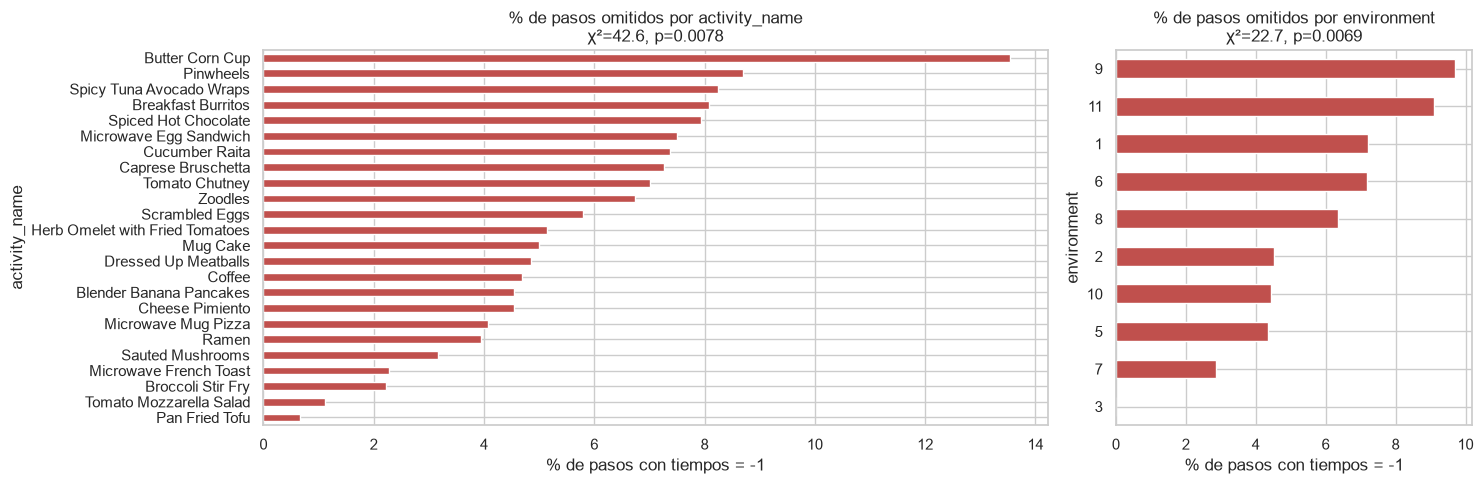

Prueba equivalente por person_id: χ²=10.4, p=0.16
Grabaciones con al menos un paso omitido: 87 de 213
Distribución de pasos omitidos por grabación: {0: 126, 1: 42, 2: 22, 3: 13, 4: 6, 5: 2, 6: 2}


In [76]:
def missing_pattern(col):
    ct = pd.crosstab(steps[col], steps["is_skipped"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rate = steps.groupby(col, observed=True)["is_skipped"].mean().mul(100)
    return chi2, p, rate

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [2.2, 1]})
for ax, col in zip(axes, ["activity_name", "environment"]):
    chi2, p, rate = missing_pattern(col)
    rate.sort_values().plot.barh(ax=ax, color="#c0504d")
    ax.set_title(f"% de pasos omitidos por {col}\nχ²={chi2:.1f}, p={p:.2g}")
    ax.set_xlabel("% de pasos con tiempos = -1")
plt.tight_layout(); plt.show()

chi2, p, _ = missing_pattern("person_id")
print(f"Prueba equivalente por person_id: χ²={chi2:.1f}, p={p:.2g}")
skip_per_rec = steps.groupby("recording_id")["is_skipped"].sum()
print("Grabaciones con al menos un paso omitido:", (skip_per_rec > 0).sum(), "de", len(skip_per_rec))
print("Distribución de pasos omitidos por grabación:", skip_per_rec.value_counts().sort_index().to_dict())

**Observaciones sobre los valores faltantes.**

- No hay `NaN` explícitos, pero **171 pasos (5.4 %) tienen inicio y fin en −1** de forma conjunta: nunca falta solo uno de los dos tiempos.
- El faltante **no es aleatorio**: 168 de esos 171 pasos están etiquetados como error *Missing Step*. El participante no ejecutó el paso, por lo que no existe un segmento de video que anotar.
- Los 3 restantes son el paso "*Top with more parmesan if desired*", que es **opcional** por definición de la receta. Es exactamente la distinción entre **variación legítima y error** que el brief señala como uno de los subproblemas centrales del proyecto.
- Existe un **patrón de ausencia por receta** (χ² significativo, p = 0.008; desde 0.7 % en *Pan Fried Tofu* hasta 13.5 % en *Butter Corn Cup*) y **por entorno** (p = 0.007), pero no por persona (p = 0.16). La omisión de pasos depende más del procedimiento y del protocolo de grabación que de quién lo ejecuta.
- 87 de 213 grabaciones (41 %) tienen al menos un paso omitido; la mayoría solo uno o dos.

### 5.5 Duplicados e inconsistencias entre fuentes

In [77]:
dup_full = steps.drop(columns=["error_tags"]).duplicated().sum()
dup_step = steps.duplicated(subset=["recording_id", "step_id"], keep=False)
print("Filas duplicadas exactas:", dup_full)
print("Pasos (recording_id, step_id) que aparecen más de una vez:", int(dup_step.sum()))
print("\nEjemplos de pasos repetidos:")
display(steps.loc[dup_step, ["recording_id", "activity_name", "step_order", "step_id", "description",
                             "start_time", "end_time"]].head(6))
print("Recetas donde ocurren repeticiones:",
      steps.loc[dup_step, "activity_name"].astype(str).value_counts().to_dict())

# ¿Cada step_id tiene una sola descripción?
n_desc = steps.groupby("step_id")["description"].nunique()
print("\nstep_id con más de una descripción:", n_desc[n_desc > 1].index.tolist())
print(steps[steps["step_id"].isin(n_desc[n_desc > 1].index)].groupby(["step_id", "description"]).size().to_string())

# Pasos omitidos que no están etiquetados como error
print("\nPasos omitidos SIN etiqueta de error:")
print(steps.loc[steps["is_skipped"] & (steps["n_error_tags"] == 0), ["recording_id", "description"]].to_string())

Filas duplicadas exactas: 0
Pasos (recording_id, step_id) que aparecen más de una vez: 79

Ejemplos de pasos repetidos:


,recording_id,activity_name,step_order,step_id,description,start_time,end_time
114,1_36,Microwave Egg Sandwich,6,10,"Microwave -Microwave just until cheese melts, ...",368.776,452.117
118,1_36,Microwave Egg Sandwich,10,10,Microwave-Microwave the ramekin cup uncovered ...,-1.000,-1.000
131,2_3,Dressed Up Meatballs,11,20,"Microwave-Microwave the plate, covered, on hig...",843.000,"1,204.600"
132,2_3,Dressed Up Meatballs,12,18,Stir-Stir the contents in the microwave with a...,"1,207.600","1,219.200"
133,2_3,Dressed Up Meatballs,13,20,"Microwave-Microwave the plate, covered, on hig...","1,228.800","1,564.800"
134,2_3,Dressed Up Meatballs,14,18,Stir-Stir the contents in the microwave with a...,"1,562.818","1,602.618"


Recetas donde ocurren repeticiones: {'Dressed Up Meatballs': 36, 'Pinwheels': 19, 'Sauted Mushrooms': 14, 'Ramen': 4, 'Microwave Egg Sandwich': 2, 'Cucumber Raita': 2, 'Herb Omelet with Fried Tomatoes': 2}

step_id con más de una descripción: [10, 25]
step_id  description                                                         
10       Microwave -Microwave just until cheese melts, about 10 seconds          10
         Microwave-Microwave the ramekin cup uncovered on high for 30 seconds     1
25       Microwave-Microwave for 1 more minute                                    8
         Microwave-Microwave for 1.5 minutes                                      1

Pasos omitidos SIN etiqueta de error:
     recording_id                            description
1718         18_3  Top-Top with more parmesan if desired
1744        18_11  Top-Top with more parmesan if desired
1770        18_27  Top-Top with more parmesan if desired


In [78]:
# Consistencia entre anotaciones y metadatos de video
meta = video_info.rename(columns={"environment_id": "env_meta", "person_id": "person_meta",
                                  "duration(sec)": "video_duration_s", "duration(min)": "video_duration_min"})
rec_keys = steps.drop_duplicates("recording_id")[["recording_id", "person_id", "environment"]]
chk = rec_keys.merge(meta, on="recording_id", how="left")
print("Grabaciones sin metadatos:", chk["video_duration_s"].isna().sum())
print("Discrepancias en environment:", (chk["environment"].astype(int) != chk["env_meta"]).sum())
print("Discrepancias en person_id:  ", (chk["person_id"].astype(int) != chk["person_meta"]).sum())
display(chk.loc[chk["person_id"].astype(int) != chk["person_meta"],
                ["recording_id", "person_id", "person_meta"]].head(10))

# ¿Algún paso termina después de que termina el video?
steps = steps.merge(meta[["recording_id", "video_duration_s"]], on="recording_id", how="left")
valid = ~steps["is_skipped"]
over = valid & (steps["end_time"] > steps["video_duration_s"] + 1)
print("Pasos que terminan más de 1 s después del fin del video:", int(over.sum()))
print("Pasos con duración <= 0 (sin contar omitidos):", int((valid & (steps["duration"] <= 0)).sum()))

Grabaciones sin metadatos: 0
Discrepancias en environment: 0
Discrepancias en person_id:   7


,recording_id,person_id,person_meta
99,15_28,4,5
102,15_33,4,8
104,16_2,1,6
107,16_18,1,6
129,18_28,4,1
135,20_26,1,4
184,26_36,4,6


Pasos que terminan más de 1 s después del fin del video: 0
Pasos con duración <= 0 (sin contar omitidos): 0


**Observaciones sobre duplicados e inconsistencias.**

- **No hay filas duplicadas.** Sí hay 79 pasos cuyo `step_id` se repite dentro de la misma grabación, concentrados en *Dressed Up Meatballs*, *Pinwheels* y *Sauted Mushrooms*. Son ciclos legítimos (por ejemplo, microondas → revolver → microondas), no errores de captura.
- **Dos `step_id` tienen dos descripciones distintas** (10 y 25), cada una con un caso discrepante: una inconsistencia menor del anotador.
- **7 grabaciones de entrenamiento tienen un `person_id` distinto** entre las anotaciones de pasos y los metadatos del video; el entorno coincide siempre.
- **Los tiempos son físicamente coherentes:** ningún paso termina después del final del video ni tiene duración negativa.

### 5.6 Tabla a nivel grabación

Se agregan los pasos por video. Las variables derivadas describen el ritmo y la calidad de ejecución, y son las que se usarán en el análisis multivariante.

In [79]:
def build_recording_table(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    v = ~d["is_skipped"]
    d["dur_valid"] = d["duration"].where(v)
    # tiempo muerto entre el fin de un paso y el inicio del siguiente (solo pasos ejecutados)
    d_sorted = d[v].sort_values(["recording_id", "start_time"])
    d_sorted["gap"] = d_sorted["start_time"] - d_sorted.groupby("recording_id")["end_time"].shift()
    gaps = d_sorted.groupby("recording_id")["gap"].agg(lambda g: g.clip(lower=0).sum())
    overlaps = d_sorted.groupby("recording_id")["gap"].agg(lambda g: (g < 0).sum())

    r = d.groupby("recording_id").agg(
        activity_name=("activity_name", "first"),
        person_id=("person_id", "first"),
        environment=("environment", "first"),
        video_duration_s=("video_duration_s", "first"),
        recording_has_errors=("recording_has_errors", "first"),
        n_steps=("step_id", "size"),
        n_skipped=("is_skipped", "sum"),
        n_error_steps=("has_errors", "sum"),
        n_error_tags=("n_error_tags", "sum"),
        mean_step_dur=("dur_valid", "mean"),
        median_step_dur=("dur_valid", "median"),
        annotated_time=("dur_valid", "sum"),
    )
    r["error_step_rate"] = r["n_error_steps"] / r["n_steps"]
    r["coverage"] = r["annotated_time"] / r["video_duration_s"]
    r["idle_time"] = gaps
    r["n_overlaps"] = overlaps
    return r

recs = build_recording_table(steps)
print("Forma de la tabla a nivel grabación:", recs.shape)
REC_NUM = ["video_duration_s", "n_steps", "n_skipped", "n_error_steps", "n_error_tags",
           "error_step_rate", "mean_step_dur", "median_step_dur", "annotated_time",
           "coverage", "idle_time", "n_overlaps"]
d = recs[REC_NUM].describe().T
d["skew"] = recs[REC_NUM].skew()
d

Forma de la tabla a nivel grabación: (213, 16)


,count,mean,std,min,25%,50%,75%,max,skew
video_duration_s,213.000,884.937,427.543,267.170,581.980,783.180,"1,096.700","2,470.330",1.264
n_steps,213.000,14.826,4.397,7.000,11.000,14.000,18.000,25.000,0.481
n_skipped,213.000,0.803,1.243,0.000,0.000,0.000,1.000,6.000,1.822
n_error_steps,213.000,4.282,5.309,0.000,0.000,1.000,8.000,22.000,1.122
n_error_tags,213.000,5.352,7.170,0.000,0.000,1.000,9.000,34.000,1.507
error_step_rate,213.000,0.297,0.344,0.000,0.000,0.083,0.647,1.000,0.633
mean_step_dur,213.000,52.458,20.411,13.858,39.024,49.728,62.698,158.516,1.124
median_step_dur,213.000,38.417,16.690,10.665,25.683,37.123,48.135,93.957,0.627
annotated_time,213.000,752.068,422.803,139.357,473.579,644.221,977.276,"2,853.295",1.470
coverage,213.000,0.832,0.154,0.347,0.763,0.867,0.928,1.529,-0.436


In [80]:
print("Variable objetivo a nivel grabación (recording_has_errors):")
display(pd.DataFrame({"n": recs["recording_has_errors"].value_counts(),
                      "%": 100 * recs["recording_has_errors"].value_counts(normalize=True)}))
print("Grabaciones con cobertura > 1 (pasos que suman más tiempo que el video):", (recs["coverage"] > 1).sum())
print("Grabaciones con pasos solapados:", (recs["n_overlaps"] > 0).sum())

Variable objetivo a nivel grabación (recording_has_errors):


,n,%
recording_has_errors,,
True,123,57.746
False,90,42.254


Grabaciones con cobertura > 1 (pasos que suman más tiempo que el video): 11
Grabaciones con pasos solapados: 121


**Observaciones a nivel grabación.**

- Las grabaciones duran entre 4.5 y 41 minutos (mediana 13 min), con distribución sesgada a la derecha.
- La anotación cubre en mediana el 87 % del video; el resto es tiempo muerto entre pasos (mediana de 105 s por grabación).
- **121 de 213 grabaciones tienen pasos que se solapan en el tiempo** y 11 tienen una "cobertura" mayor al 100 %. En cocina, varios pasos ocurren **en paralelo** (algo se calienta en el microondas mientras se corta otra cosa). Esto confirma con datos la decisión del brief de modelar el SOP como un **grafo de orden parcial** y no como una lista lineal.
- A nivel grabación, el 57.7 % de los videos contiene al menos un error: las clases están razonablemente balanceadas en esta granularidad.

## 6. Análisis univariante

La elección del gráfico depende de la escala de cada variable: **histograma + boxplot** para numéricas continuas (forma de la distribución y atípicos), **gráfico de barras** para categóricas y discretas (frecuencia por clase).

### 6.1 Variables numéricas a nivel paso

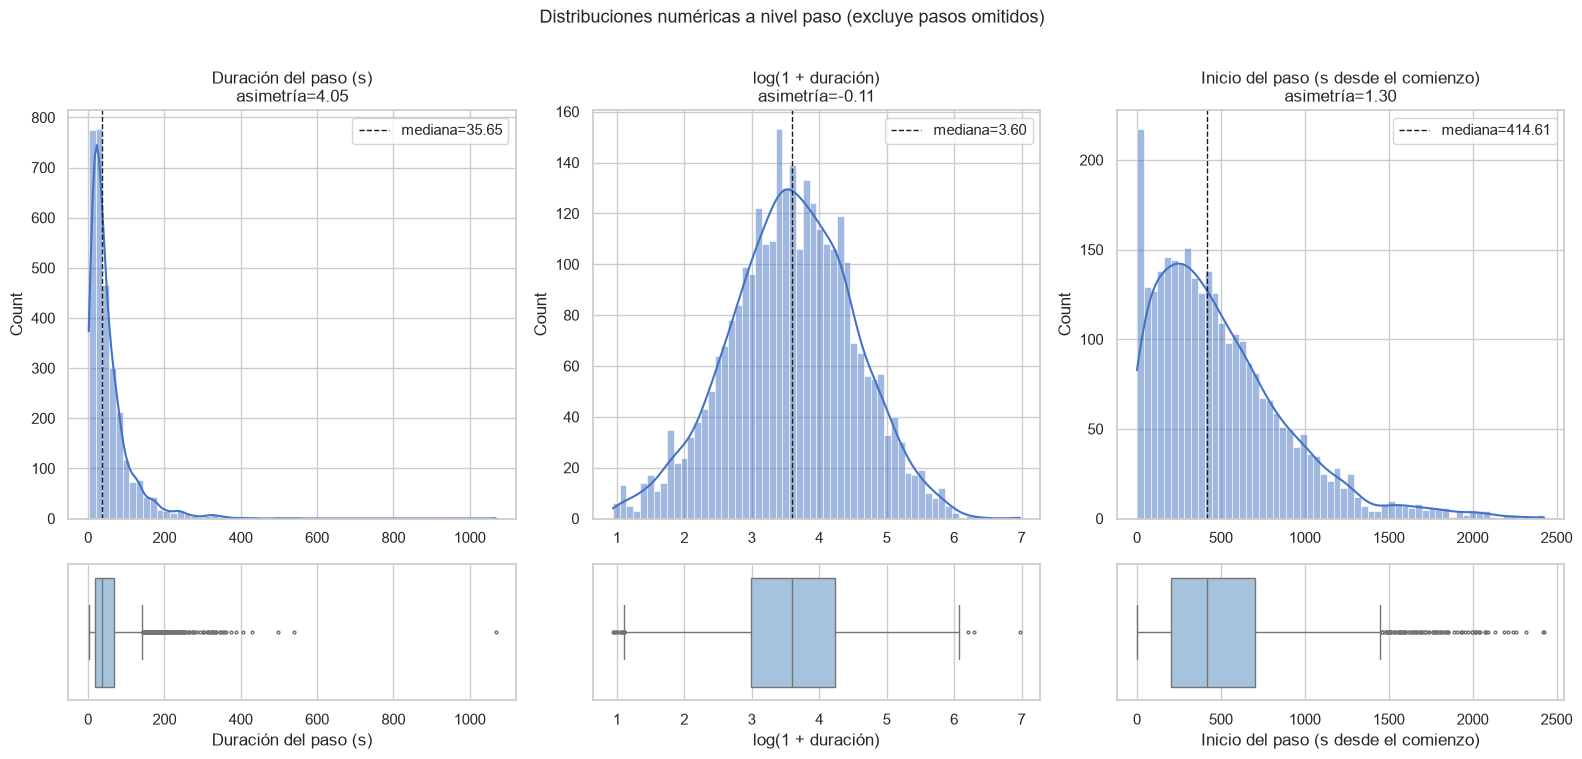

In [81]:
v = steps.loc[~steps["is_skipped"]]
fig, axes = plt.subplots(2, 3, figsize=(16, 7.5), gridspec_kw={"height_ratios": [3, 1]})
specs = [("duration", "Duración del paso (s)", False),
         ("duration", "log(1 + duración)", True),
         ("start_time", "Inicio del paso (s desde el comienzo)", False)]
for i, (col, title, log) in enumerate(specs):
    x = np.log1p(v[col]) if log else v[col]
    sns.histplot(x, bins=60, kde=True, ax=axes[0, i], color="#4472c4")
    axes[0, i].axvline(x.median(), color="k", ls="--", lw=1, label=f"mediana={x.median():.2f}")
    axes[0, i].set_title(f"{title}\nasimetría={stats.skew(x):.2f}")
    axes[0, i].legend(); axes[0, i].set_xlabel("")
    sns.boxplot(x=x, ax=axes[1, i], color="#9dc3e6", fliersize=2)
    axes[1, i].set_xlabel(title)
plt.suptitle("Distribuciones numéricas a nivel paso (excluye pasos omitidos)", y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

In [82]:
# Normalidad: Shapiro sobre una muestra (n<=5000) y D'Agostino sobre todo
for name, x in [("duración", v["duration"]), ("log1p(duración)", np.log1p(v["duration"]))]:
    k2, p_k2 = stats.normaltest(x)
    print(f"{name:18s} D'Agostino K²={k2:9.1f}  p={p_k2:.2e}  asimetría={stats.skew(x):6.2f}  curtosis={stats.kurtosis(x):6.2f}")

duración           D'Agostino K²=   2716.8  p=0.00e+00  asimetría=  4.05  curtosis= 38.38
log1p(duración)    D'Agostino K²=      6.9  p=3.24e-02  asimetría= -0.11  curtosis= -0.08


**Observaciones.**

- La duración tiene una cola derecha larga, con la mayoría de los pasos entre 16 y 65 s. El boxplot en escala original marca muchos puntos como atípicos.
- Con **`log1p`** la distribución se vuelve casi simétrica: la asimetría pasa de 4.05 a −0.11 y la curtosis de 38 a prácticamente 0. La prueba de D'Agostino aún rechaza normalidad estricta (p = 0.03) por el tamaño de muestra, pero el estadístico cae de 2,717 a 6.9: la forma es muy cercana a la normal. La duración de los pasos sigue aproximadamente una distribución **log-normal**, típica de tiempos de tarea.
- `start_time` también es asimétrica, como reflejo de que algunas grabaciones son mucho más largas que otras.

### 6.2 Variables numéricas a nivel grabación

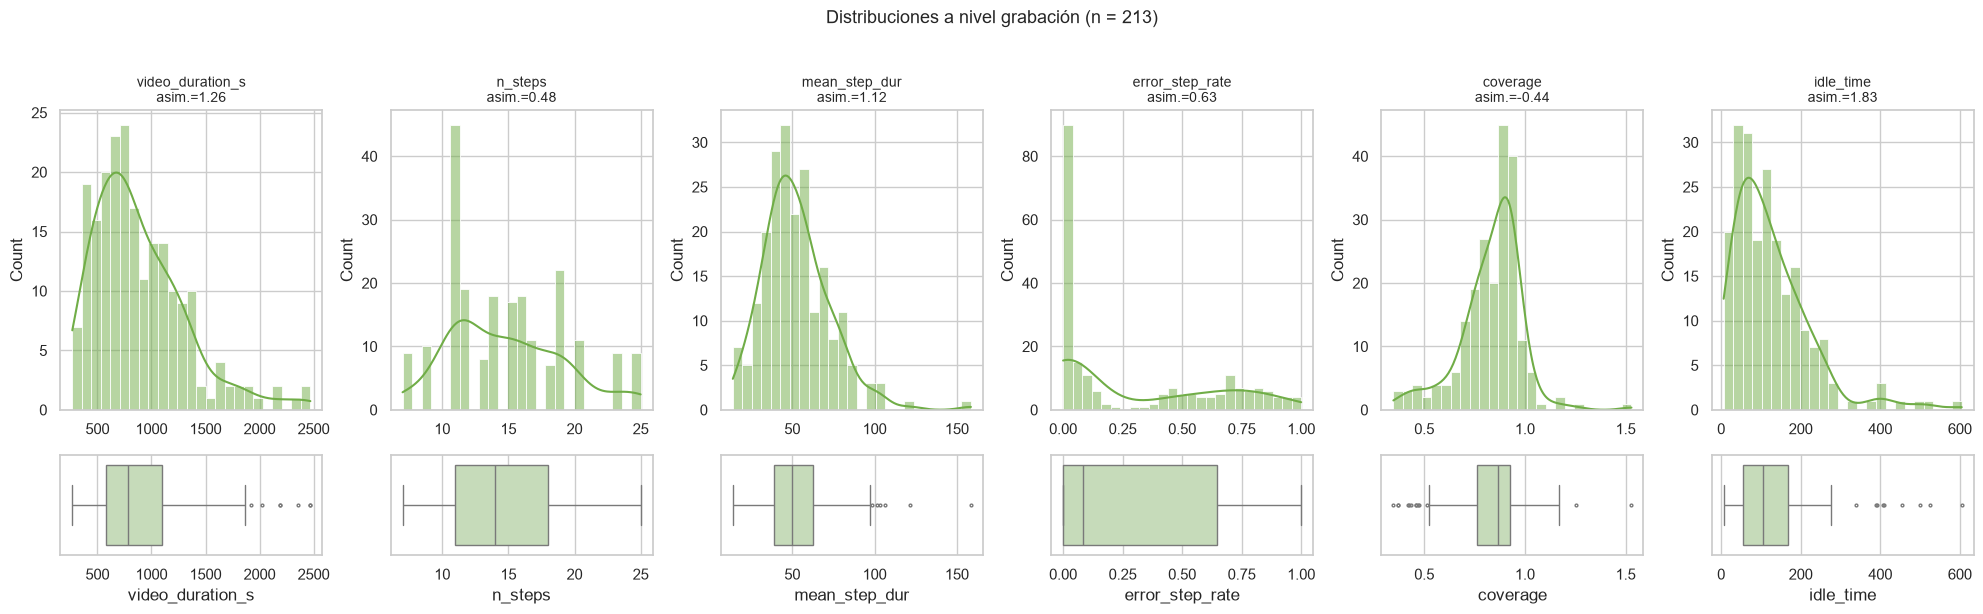

In [83]:
plot_cols = ["video_duration_s", "n_steps", "mean_step_dur", "error_step_rate", "coverage", "idle_time"]
fig, axes = plt.subplots(2, 6, figsize=(20, 6), gridspec_kw={"height_ratios": [3, 1]})
for i, col in enumerate(plot_cols):
    sns.histplot(recs[col], bins=25, kde=True, ax=axes[0, i], color="#70ad47")
    axes[0, i].set_title(f"{col}\nasim.={recs[col].skew():.2f}", fontsize=10)
    axes[0, i].set_xlabel("")
    sns.boxplot(x=recs[col], ax=axes[1, i], color="#c5e0b4", fliersize=2)
plt.suptitle("Distribuciones a nivel grabación (n = %d)" % len(recs), y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

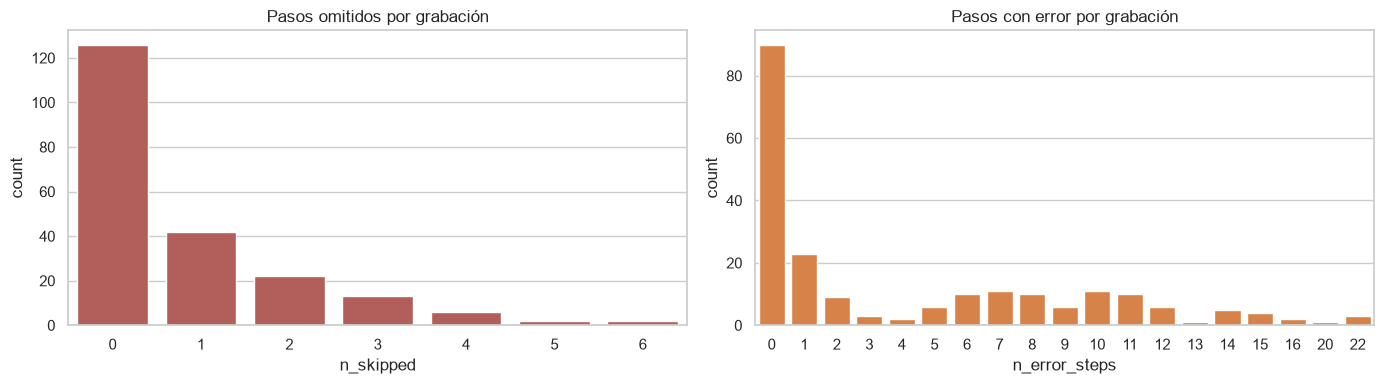

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(x=recs["n_skipped"], ax=axes[0], color="#c0504d")
axes[0].set_title("Pasos omitidos por grabación"); axes[0].set_xlabel("n_skipped")
sns.countplot(x=recs["n_error_steps"], ax=axes[1], color="#ed7d31")
axes[1].set_title("Pasos con error por grabación"); axes[1].set_xlabel("n_error_steps")
plt.tight_layout(); plt.show()

**Observaciones.**

- `error_step_rate` es **bimodal**: un grupo grande de grabaciones sin errores (0 %) y otro con tasas altas. Esto refleja el diseño del dataset, donde a una parte de los participantes se les pidió ejecutar la receta con errores intencionales.
- La mayoría de las grabaciones no omite ningún paso. El número de pasos con error tiene una cola larga que llega hasta 22 en un mismo video.
- `idle_time` y `video_duration_s` tienen asimetría positiva: hay pocas grabaciones muy largas y con mucho tiempo muerto.

### 6.3 Variables categóricas

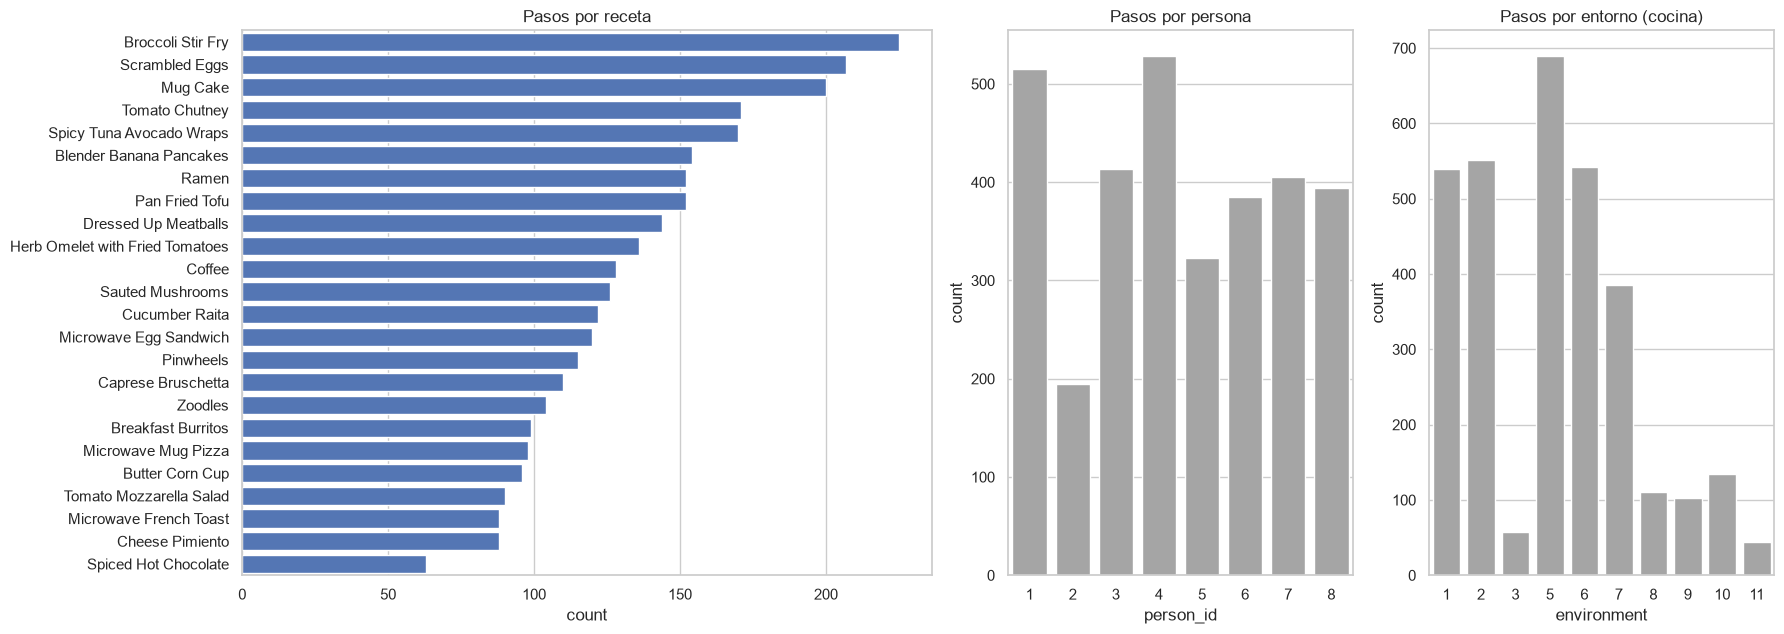

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), gridspec_kw={"width_ratios": [2, 1, 1]})
order = steps["activity_name"].astype(str).value_counts().index
sns.countplot(y=steps["activity_name"].astype(str), order=order, ax=axes[0], color="#4472c4")
axes[0].set_title("Pasos por receta"); axes[0].set_ylabel("")
sns.countplot(x=steps["person_id"], ax=axes[1], color="#a5a5a5"); axes[1].set_title("Pasos por persona")
sns.countplot(x=steps["environment"], ax=axes[2], color="#a5a5a5"); axes[2].set_title("Pasos por entorno (cocina)")
plt.tight_layout(); plt.show()

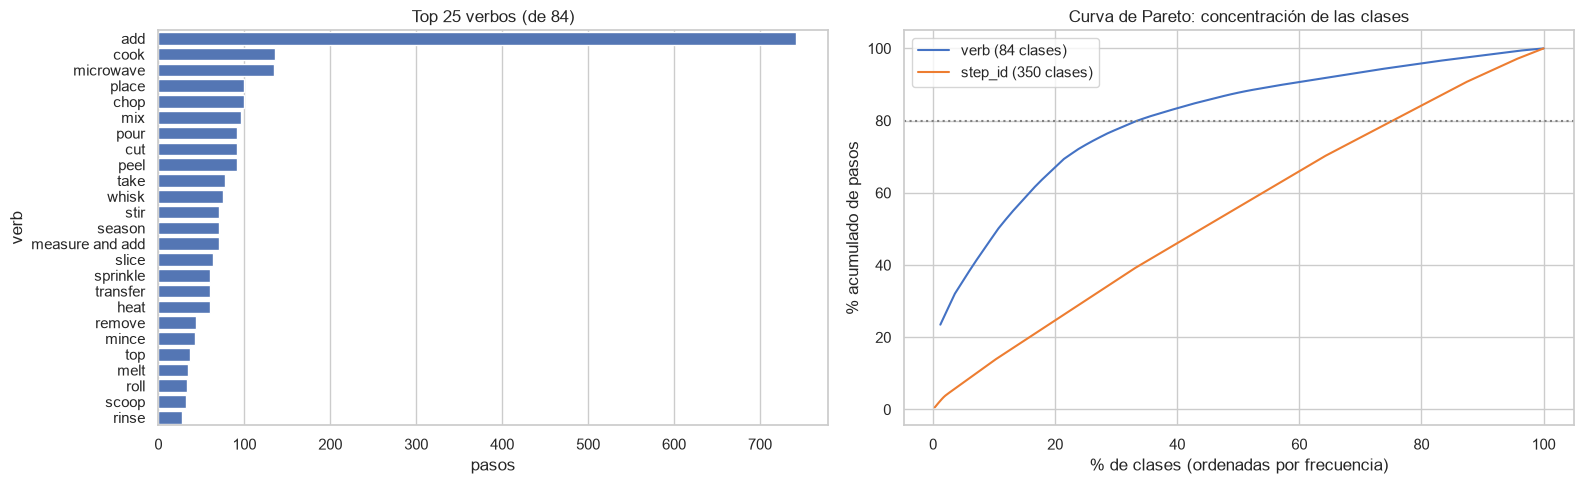

verb: 29 de 84 clases (35 %) cubren el 80 % de los pasos; 22 clases tienen menos de 10 pasos; mediana de frecuencia = 14
step_id: 264 de 350 clases (75 %) cubren el 80 % de los pasos; 235 clases tienen menos de 10 pasos; mediana de frecuencia = 9


In [86]:
# Alta cardinalidad: curva de Pareto de verbos y de step_id
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
vc = steps["verb"].astype(str).value_counts()
top = vc.head(25)
sns.barplot(x=top.values, y=top.index, ax=axes[0], color="#4472c4")
axes[0].set_title(f"Top 25 verbos (de {len(vc)})"); axes[0].set_xlabel("pasos")

for col, color in [("verb", "#4472c4"), ("step_id", "#ed7d31")]:
    c = steps[col].astype(str).value_counts()
    cum = 100 * c.cumsum() / c.sum()
    axes[1].plot(np.arange(1, len(c) + 1) / len(c) * 100, cum.values, label=f"{col} ({len(c)} clases)", color=color)
axes[1].axhline(80, color="gray", ls=":")
axes[1].set_xlabel("% de clases (ordenadas por frecuencia)"); axes[1].set_ylabel("% acumulado de pasos")
axes[1].set_title("Curva de Pareto: concentración de las clases"); axes[1].legend()
plt.tight_layout(); plt.show()

for col in ["verb", "step_id"]:
    c = steps[col].astype(str).value_counts()
    k80 = (c.cumsum() / c.sum() <= 0.80).sum() + 1
    print(f"{col}: {k80} de {len(c)} clases ({100*k80/len(c):.0f} %) cubren el 80 % de los pasos; "
          f"{(c < 10).sum()} clases tienen menos de 10 pasos; mediana de frecuencia = {c.median():.0f}")

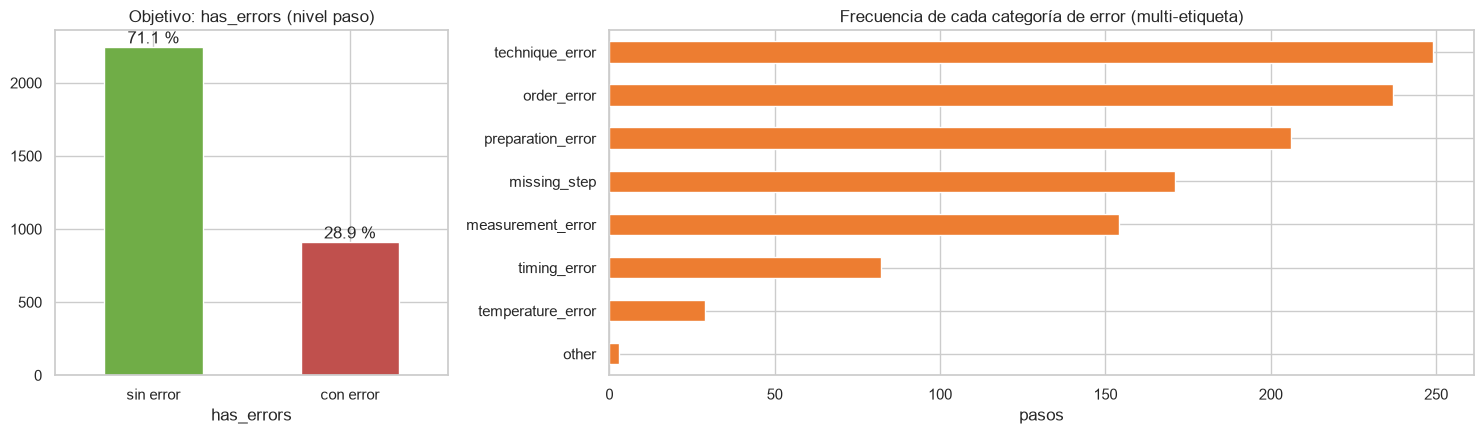

In [87]:
# Variable objetivo y tipos de error
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 2.2]})
steps["has_errors"].value_counts().rename({False: "sin error", True: "con error"}).plot.bar(
    ax=axes[0], color=["#70ad47", "#c0504d"], rot=0)
axes[0].set_title("Objetivo: has_errors (nivel paso)")
for p in axes[0].patches:
    axes[0].annotate(f"{100*p.get_height()/len(steps):.1f} %", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")
tag_freq.rename(lambda c: c.replace("err_", "")).plot.barh(ax=axes[1], color="#ed7d31")
axes[1].invert_yaxis(); axes[1].set_title("Frecuencia de cada categoría de error (multi-etiqueta)")
axes[1].set_xlabel("pasos")
plt.tight_layout(); plt.show()

**Observaciones.**

- Las recetas aportan entre 2 % y 7 % de los pasos cada una: no hay una receta dominante.
- **Curva de Pareto:** en `verb`, 29 de 84 clases (35 %) cubren el 80 % de los pasos, así que agrupar la cola larga pierde poca información. En `step_id` la curva es casi diagonal: hacen falta 264 de 350 clases para cubrir el 80 %, y 235 clases tienen menos de 10 ejemplos. **Un one-hot de `step_id` sería inviable** y llevaría directamente al sobreajuste.
- **Desbalanceo:** el objetivo binario está en proporción 71 / 29 (moderado). Las categorías de error, en cambio, tienen un desbalanceo severo: *Other* aparece 83 veces menos que *Technique Error*.

## 7. Análisis bivariante y multivariante

### 7.1 Correlación entre variables numéricas (nivel grabación)

Se reportan **Pearson** (relación lineal) y **Spearman** (relación monótona, robusta a la asimetría y a los atípicos detectados en la sección 6). Si ambas difieren mucho, la relación está dominada por valores extremos o no es lineal.

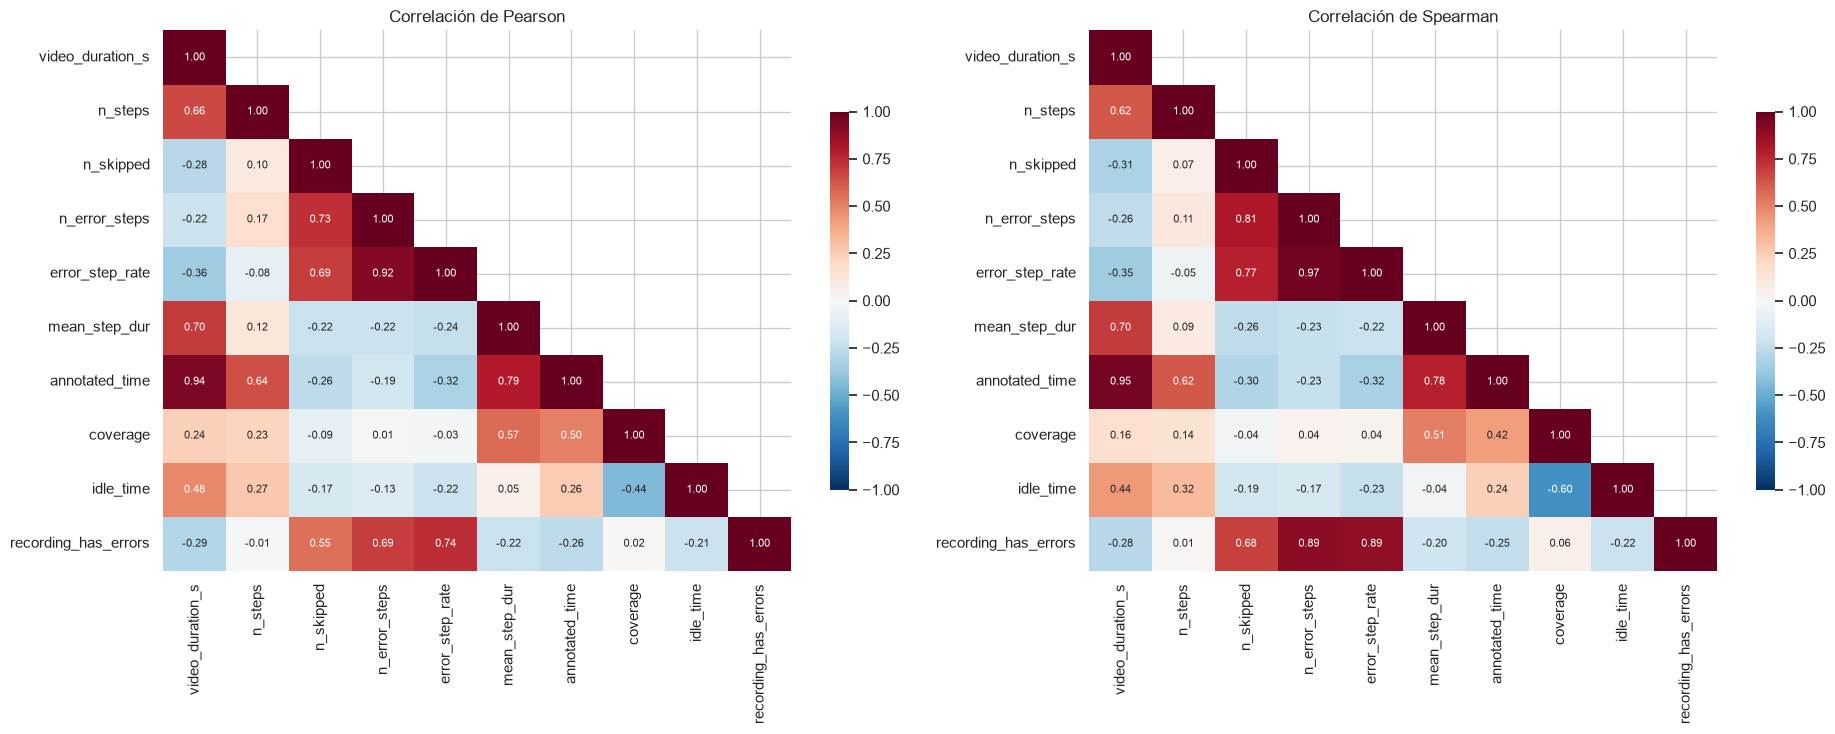

In [88]:
corr_cols = ["video_duration_s", "n_steps", "n_skipped", "n_error_steps", "error_step_rate",
             "mean_step_dur", "annotated_time", "coverage", "idle_time"]
rc = recs[corr_cols].assign(recording_has_errors=recs["recording_has_errors"].astype(int))
fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))
for ax, method in zip(axes, ["pearson", "spearman"]):
    m = rc.corr(method=method)
    mask = np.triu(np.ones_like(m, dtype=bool), k=1)
    sns.heatmap(m, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                ax=ax, cbar_kws={"shrink": .7}, annot_kws={"size": 8})
    ax.set_title(f"Correlación de {method.capitalize()}")
plt.tight_layout(); plt.show()

In [89]:
# Pares con correlación de Spearman |rho| >= 0.5 y su significancia
pairs = []
for i, a in enumerate(rc.columns):
    for b in rc.columns[i+1:]:
        rho, p = stats.spearmanr(rc[a], rc[b])
        r, _ = stats.pearsonr(rc[a], rc[b])
        if abs(rho) >= 0.5:
            pairs.append((a, b, r, rho, p))
pd.DataFrame(pairs, columns=["var_1", "var_2", "pearson", "spearman", "p_spearman"]).sort_values(
    "spearman", key=abs, ascending=False)

,var_1,var_2,pearson,spearman,p_spearman
7,n_error_steps,error_step_rate,0.920,0.966,0.000
2,video_duration_s,annotated_time,0.943,0.955,0.000
8,n_error_steps,recording_has_errors,0.692,0.891,0.000
9,error_step_rate,recording_has_errors,0.740,0.890,0.000
4,n_skipped,n_error_steps,0.730,0.807,0.000
10,mean_step_dur,annotated_time,0.794,0.777,0.000
5,n_skipped,error_step_rate,0.688,0.775,0.000
1,video_duration_s,mean_step_dur,0.696,0.700,0.000
6,n_skipped,recording_has_errors,0.554,0.683,0.000
3,n_steps,annotated_time,0.642,0.623,0.000


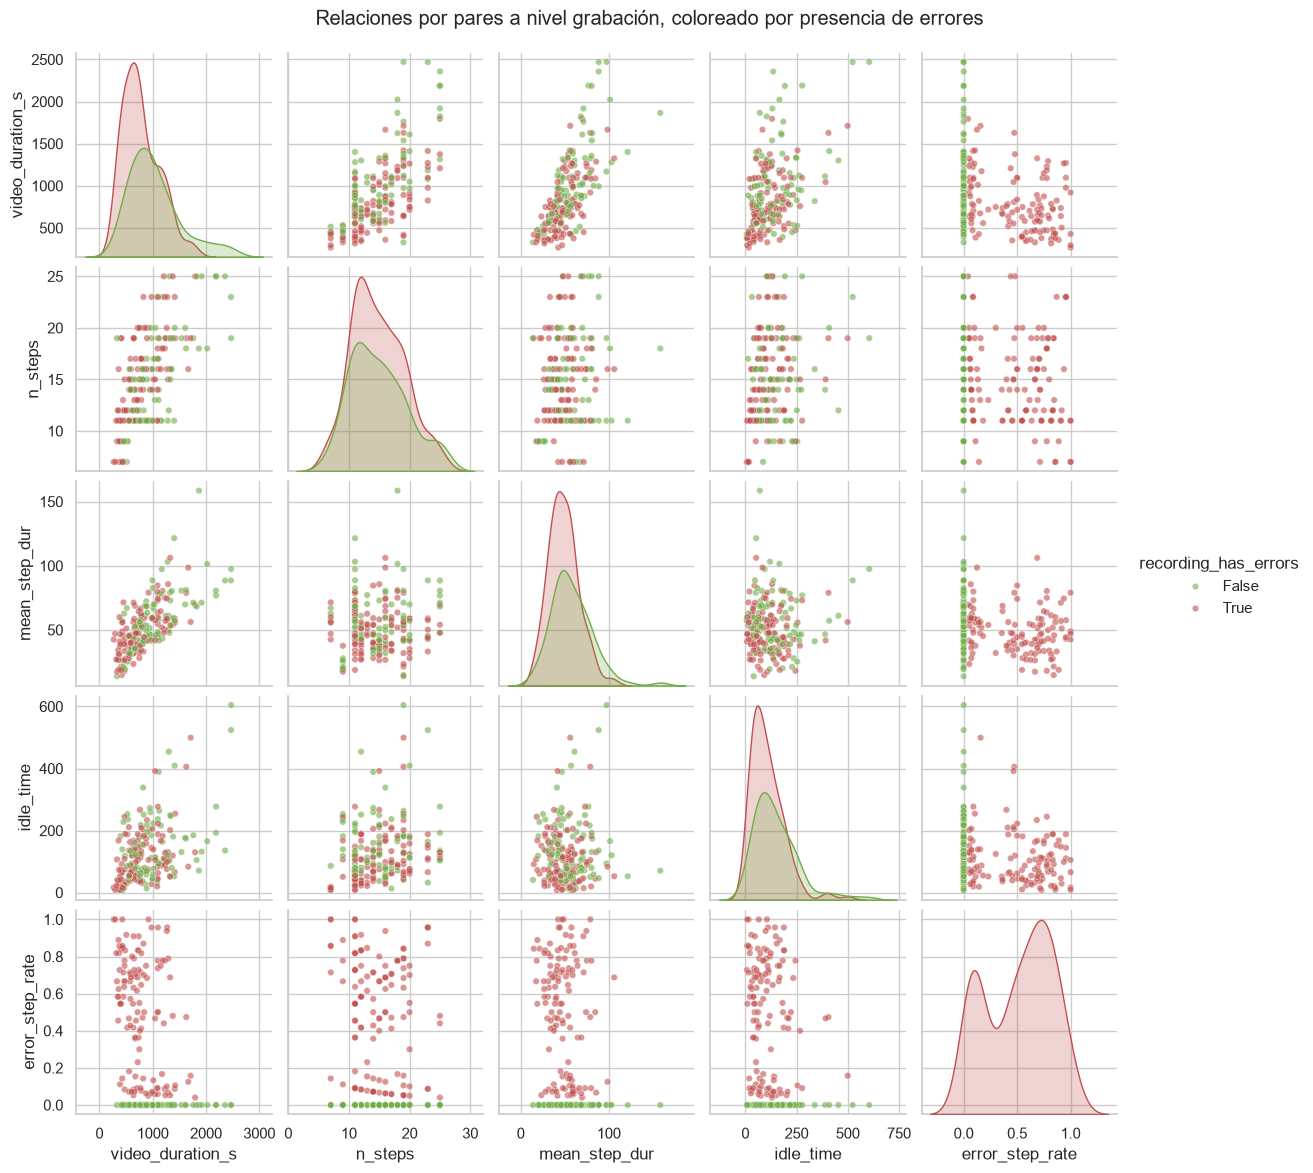

In [90]:
g = sns.pairplot(recs[["video_duration_s", "n_steps", "mean_step_dur", "idle_time", "error_step_rate",
                       "recording_has_errors"]],
                 hue="recording_has_errors", palette={False: "#70ad47", True: "#c0504d"},
                 plot_kws={"alpha": .6, "s": 22}, diag_kind="kde", height=2.3)
g.figure.suptitle("Relaciones por pares a nivel grabación, coloreado por presencia de errores", y=1.02)
plt.show()

**Observaciones.**

- **Redundancias claras:** `n_error_steps` y `error_step_rate` (ρ = 0.97) miden casi lo mismo; también `video_duration_s` y `annotated_time` (ρ = 0.96). Para el modelado basta con una variable de cada par.
- **La omisión de pasos está fuertemente asociada con los demás errores** (ρ = 0.81 entre `n_skipped` y `n_error_steps`): quien omite pasos tiende a cometer otros errores en la misma grabación.
- Spearman es claramente mayor que Pearson en las relaciones con `recording_has_errors` (0.89 contra 0.69), lo que indica relaciones monótonas pero no lineales, consistentes con la distribución bimodal de la tasa de error.
- **Las grabaciones con error son más cortas** (mediana de 716 s contra 920 s) y tienen menos tiempo muerto (87 s contra 124 s). Es coherente con pasos omitidos o ejecutados con prisa, y sugiere que el ritmo de ejecución es una señal útil.
- `coverage` e `idle_time` tienen correlación negativa (ρ = −0.60), como era de esperar.

### 7.2 Variables numéricas frente a la variable objetivo (nivel paso)

Para una numérica contra una binaria se usa la correlación **punto-biserial** y la prueba de **Mann-Whitney U** (no asume normalidad, adecuado dada la asimetría observada).

In [91]:
v = steps.loc[~steps["is_skipped"]].copy()
v["log_duration"] = np.log1p(v["duration"])
v["rel_position"] = v["step_order"] / v.groupby("recording_id")["step_order"].transform("max")
v["rel_start"] = v["start_time"] / v["video_duration_s"]

rows = []
for col in ["duration", "log_duration", "start_time", "step_order", "rel_position", "rel_start"]:
    rpb, p_rpb = stats.pointbiserialr(v["has_errors"].astype(int), v[col])
    u, p_u = stats.mannwhitneyu(v.loc[v["has_errors"], col], v.loc[~v["has_errors"], col])
    rows.append((col, v.loc[~v["has_errors"], col].median(), v.loc[v["has_errors"], col].median(), rpb, p_rpb, p_u))
pd.DataFrame(rows, columns=["variable", "mediana_sin_error", "mediana_con_error",
                            "r_punto_biserial", "p_rpb", "p_mann_whitney"])

,variable,mediana_sin_error,mediana_con_error,r_punto_biserial,p_rpb,p_mann_whitney
0,duration,34.829,37.679,-0.011,0.552,0.176
1,log_duration,3.579,3.655,0.020,0.284,0.176
2,start_time,449.220,323.177,-0.182,0.000,0.000
3,step_order,7.000,5.000,-0.129,0.000,0.000
4,rel_position,0.500,0.447,-0.068,0.000,0.000
5,rel_start,0.522,0.489,-0.050,0.006,0.005


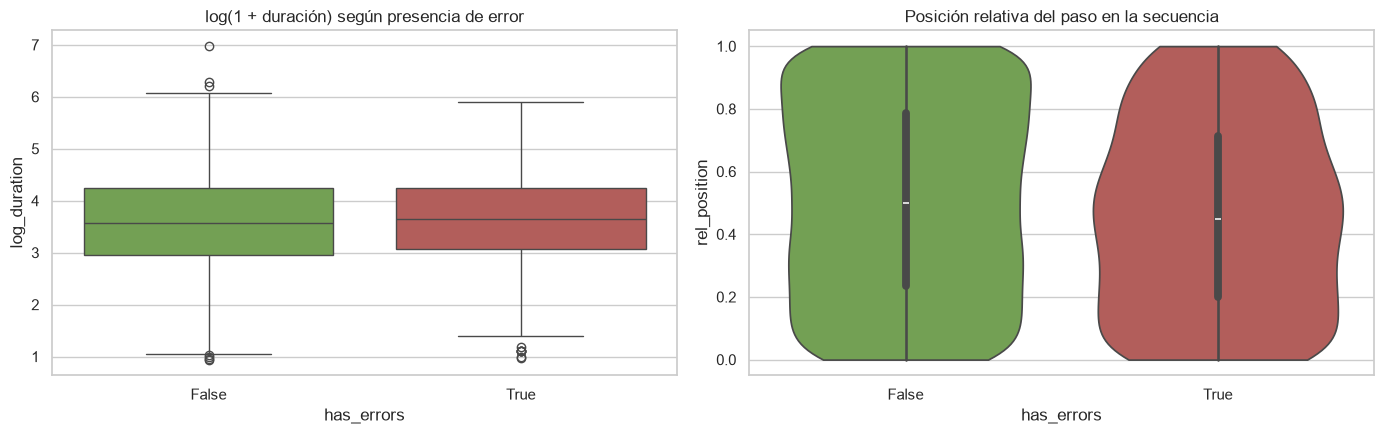

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=v, x="has_errors", y="log_duration", ax=axes[0], palette=["#70ad47", "#c0504d"],
            hue="has_errors", legend=False)
axes[0].set_title("log(1 + duración) según presencia de error")
sns.violinplot(data=v, x="has_errors", y="rel_position", ax=axes[1], palette=["#70ad47", "#c0504d"],
               hue="has_errors", legend=False, cut=0)
axes[1].set_title("Posición relativa del paso en la secuencia")
plt.tight_layout(); plt.show()

**Observaciones.**

- **La duración del paso por sí sola no distingue pasos con y sin error** (Mann-Whitney p = 0.18; correlación punto-biserial ≈ 0). La duración absoluta mezcla acciones de escalas muy distintas, así que en 8.3 se construye una versión relativa a la duración típica de cada paso.
- **Los errores ocurren antes en el procedimiento:** los pasos con error tienen una mediana de inicio de 323 s contra 449 s, y su posición relativa en la secuencia también es menor. El efecto es estadísticamente significativo pero pequeño (|r| < 0.2).

### 7.3 Variables categóricas frente a la variable objetivo

Para pares categórica–categórica se usa **χ² de independencia** y su tamaño de efecto, la **V de Cramér** (0 = independencia, 1 = asociación perfecta), con la corrección de sesgo de Bergsma (2013) porque varias variables tienen muchas clases.

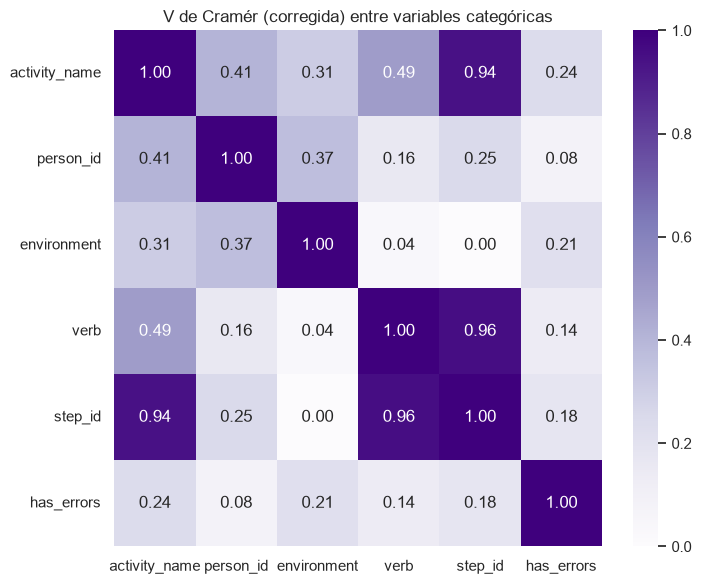

,variable,chi2,gl,p,V_Cramer_vs_has_errors
0,activity_name,198.440,23,0.000,0.236
2,environment,154.773,9,0.000,0.215
4,step_id,453.930,349,0.000,0.182
3,verb,142.960,83,0.000,0.138
1,person_id,29.744,7,0.000,0.085


In [93]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum(); r, k = ct.shape
    phi2 = chi2 / n
    phi2c = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rc_, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2c / max(1e-12, min(kc - 1, rc_ - 1)))

cat_vars = ["activity_name", "person_id", "environment", "verb", "step_id", "has_errors"]
cv = pd.DataFrame(index=cat_vars, columns=cat_vars, dtype=float)
for a in cat_vars:
    for b in cat_vars:
        cv.loc[a, b] = cramers_v(steps[a].astype(str), steps[b].astype(str))

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cv, annot=True, fmt=".2f", cmap="Purples", vmin=0, vmax=1, ax=ax)
ax.set_title("V de Cramér (corregida) entre variables categóricas")
plt.tight_layout(); plt.show()

res = []
for c in cat_vars[:-1]:
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(steps[c].astype(str), steps["has_errors"]))
    res.append((c, chi2, dof, p, cv.loc[c, "has_errors"]))
pd.DataFrame(res, columns=["variable", "chi2", "gl", "p", "V_Cramer_vs_has_errors"]).sort_values(
    "V_Cramer_vs_has_errors", ascending=False)

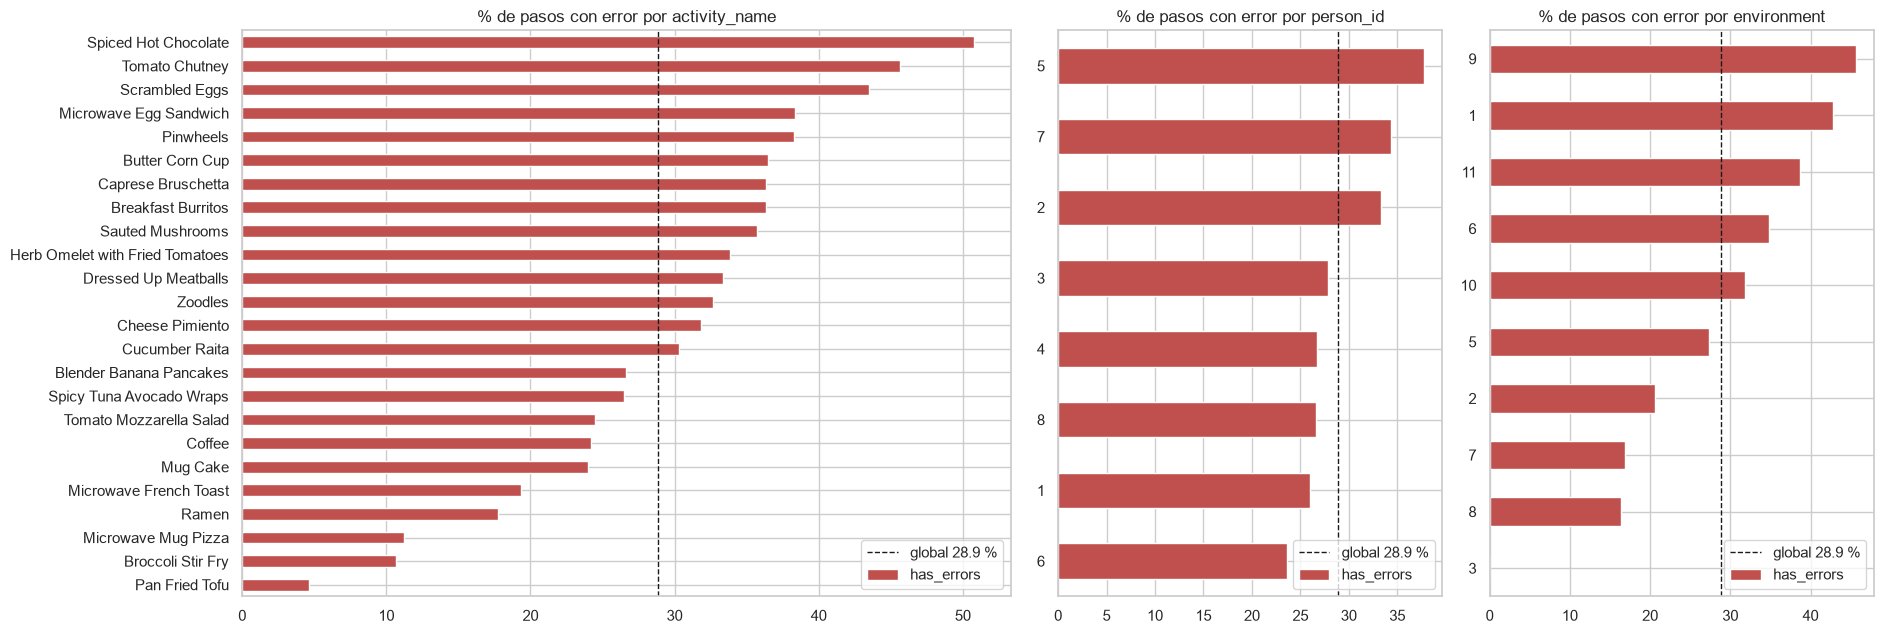

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5), gridspec_kw={"width_ratios": [2, 1, 1]})
base = steps["has_errors"].mean() * 100
for ax, col in zip(axes, ["activity_name", "person_id", "environment"]):
    rate = steps.groupby(col, observed=True)["has_errors"].mean().mul(100).sort_values()
    rate.plot.barh(ax=ax, color="#c0504d")
    ax.axvline(base, color="k", ls="--", lw=1, label=f"global {base:.1f} %")
    ax.set_title(f"% de pasos con error por {col}"); ax.set_ylabel(""); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

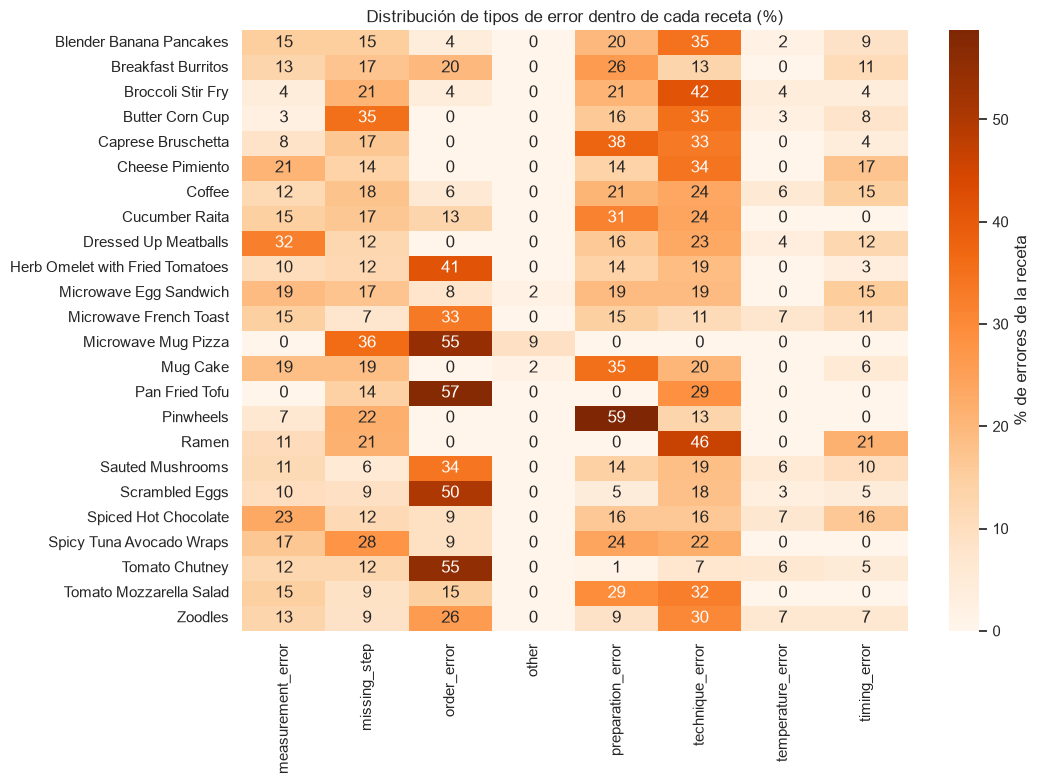

In [95]:
# Composición de los errores por receta (normalizado por fila)
err_by_act = steps.groupby("activity_name", observed=True)[tag_cols].sum()
err_by_act.columns = [c.replace("err_", "") for c in err_by_act.columns]
share = err_by_act.div(err_by_act.sum(axis=1), axis=0).mul(100)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(share, annot=True, fmt=".0f", cmap="Oranges", ax=ax, cbar_kws={"label": "% de errores de la receta"})
ax.set_title("Distribución de tipos de error dentro de cada receta (%)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

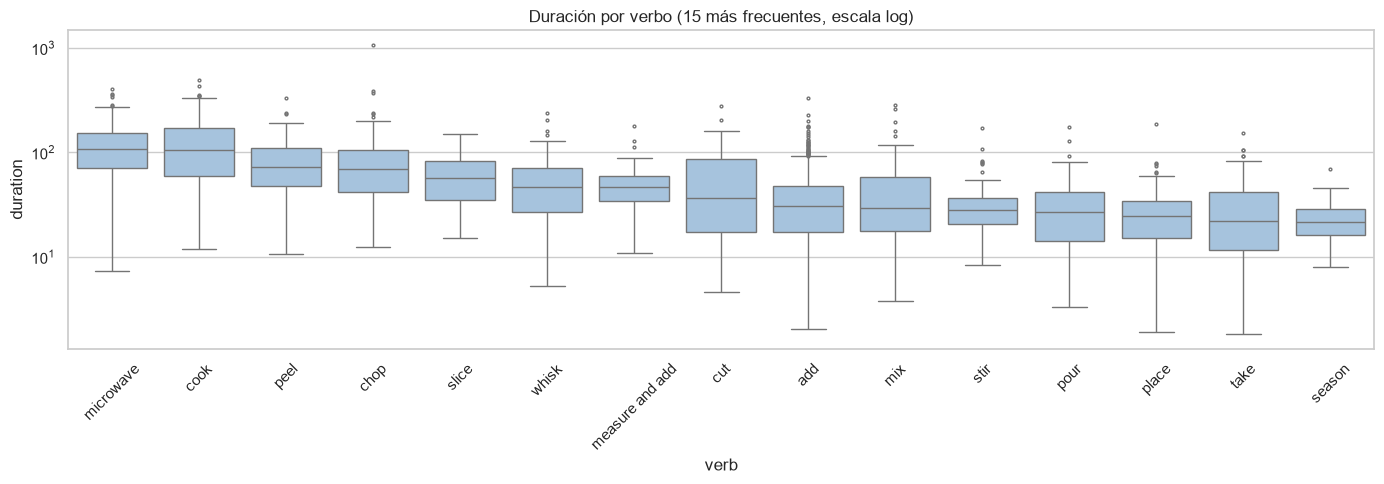

In [96]:
# Duración por verbo: ¿los atípicos de duración corresponden a ciertas acciones?
top_verbs = steps["verb"].astype(str).value_counts().head(15).index
vv = v[v["verb"].astype(str).isin(top_verbs)]
order = vv.groupby("verb", observed=True)["duration"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=vv, x="verb", y="duration", order=order, ax=ax, color="#9dc3e6", fliersize=2)
ax.set_yscale("log"); ax.set_title("Duración por verbo (15 más frecuentes, escala log)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Observaciones.**

- **Receta** (V = 0.24) y **entorno** (V = 0.21) son las variables categóricas más asociadas al error. La tasa de error va de 4.6 % (*Pan Fried Tofu*) a 50.8 % (*Spiced Hot Chocolate*).
- **La asociación con el entorno es un artefacto del protocolo de recolección**, no un efecto real de la cocina. Por ejemplo, el entorno 3 tiene 0 % de errores porque sus 4 grabaciones de entrenamiento son todas sin error, y el entorno 1 tiene 27 de 37 grabaciones con error. Un modelo que use el entorno como predictor aprendería qué cocina se usó para grabar errores, y eso no se transfiere a la planta del cliente.
- `person_id` se asocia débilmente con el error (V = 0.08), lo cual es deseable: el error no depende de quién ejecuta.
- **Redundancia entre categóricas:** `step_id` determina casi por completo la receta (V = 0.94) y el verbo (V = 0.96). Incluirlas todas sería redundante.
- **El tipo de error dominante cambia según la receta.** Los errores de orden van de 0 % de los errores en algunas recetas a 57 % en otras, probablemente porque solo pueden ocurrir donde la receta tiene pasos que se pueden ejecutar en otro orden.
- **Duración por verbo:** las acciones como *cook*, *microwave*, *toast* o *simmer* son de un orden de magnitud más largas que *add* o *place*. Esto confirma que la duración debe interpretarse en relación con la acción.

### 7.4 Tendencias temporales

El dataset no tiene una dimensión de calendario, pero sí una dimensión temporal **dentro de cada grabación**: la posición del paso en el procedimiento. Se analiza si la tasa de error y la duración cambian a lo largo de la ejecución.

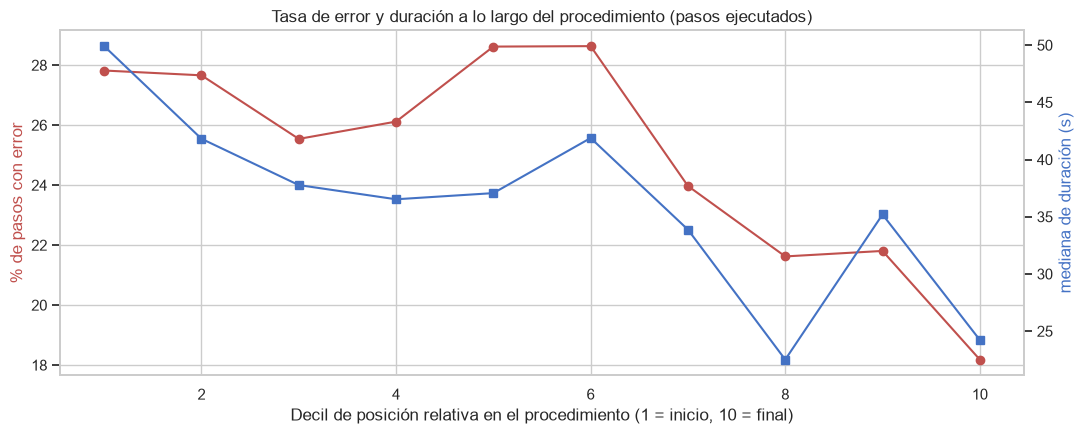

Spearman posición relativa vs error: rho=-0.068, p=0.00021


,error_rate,median_dur,n
pos_decile,,,
1,27.820,49.911,399
2,27.660,41.816,282
3,25.540,37.767,278
4,26.117,36.526,291
5,28.617,37.064,311
6,28.632,41.880,234
7,23.970,33.873,267
8,21.622,22.513,296
9,21.805,35.197,266


In [97]:
v["pos_decile"] = pd.cut(v["rel_position"], bins=np.linspace(0, 1, 11), include_lowest=True, labels=range(1, 11))
tr = v.groupby("pos_decile", observed=True).agg(error_rate=("has_errors", "mean"),
                                                 median_dur=("duration", "median"), n=("has_errors", "size"))
tr["error_rate"] *= 100

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(tr.index.astype(int), tr["error_rate"], marker="o", color="#c0504d", label="% de pasos con error")
ax1.set_xlabel("Decil de posición relativa en el procedimiento (1 = inicio, 10 = final)")
ax1.set_ylabel("% de pasos con error", color="#c0504d")
ax2 = ax1.twinx()
ax2.plot(tr.index.astype(int), tr["median_dur"], marker="s", color="#4472c4", label="mediana de duración (s)")
ax2.set_ylabel("mediana de duración (s)", color="#4472c4"); ax2.grid(False)
ax1.set_title("Tasa de error y duración a lo largo del procedimiento (pasos ejecutados)")
plt.tight_layout(); plt.show()

rho, p = stats.spearmanr(v["rel_position"], v["has_errors"].astype(int))
print(f"Spearman posición relativa vs error: rho={rho:.3f}, p={p:.2g}")
display(tr)

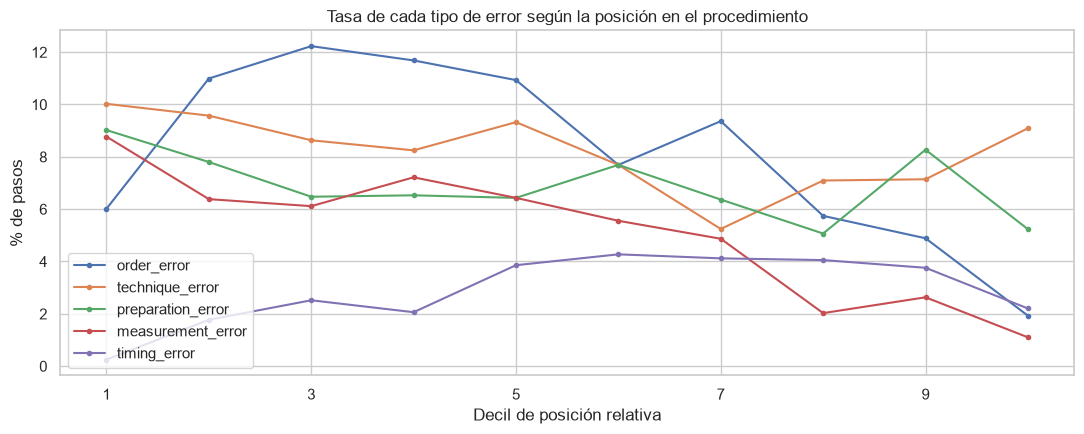

In [98]:
# Errores de orden: ¿dónde ocurren?
oe = v.groupby("pos_decile", observed=True)[[c for c in tag_cols if c != "err_missing_step"]].mean().mul(100)
oe.columns = [c.replace("err_", "") for c in oe.columns]
fig, ax = plt.subplots(figsize=(11, 4.5))
oe[["order_error", "technique_error", "preparation_error", "measurement_error", "timing_error"]].plot(ax=ax, marker=".")
ax.set_title("Tasa de cada tipo de error según la posición en el procedimiento")
ax.set_xlabel("Decil de posición relativa"); ax.set_ylabel("% de pasos")
plt.tight_layout(); plt.show()

**Observaciones sobre tendencias temporales.**

- **La tasa de error disminuye hacia el final del procedimiento:** se mantiene entre 25 % y 29 % durante los primeros seis deciles y baja a 18 % en el último decil (Spearman ρ = −0.07, p < 0.001).
- **Cada tipo de error tiene su propio perfil temporal.** Los errores de **orden** se concentran en la parte media (≈11-12 % en los deciles 2 a 5) y casi desaparecen al final (1.9 %): al final quedan pocos pasos que se puedan reordenar. Los errores de **medición** son más frecuentes al inicio (8.8 %, cuando se miden ingredientes) y caen a 1.1 %. Los errores de **tiempo** (*timing*) crecen hacia la parte media-final, donde se cocina.
- La duración mediana de los pasos baja hacia el final del procedimiento (de ≈50 s a ≈24 s): los pasos finales suelen ser de emplatado o de adición rápida.
- Implicación para el proyecto: la **posición relativa** del paso es una característica útil, y el sistema debería ajustar las preguntas al experto según la fase del procedimiento.

## 8. Preprocesamiento

Cada decisión se toma con base en la evidencia de las secciones anteriores y se ajusta **solo con entrenamiento**. Al final se empaqueta en una función que se aplica igual a validación y prueba.

### 8.1 Valores faltantes: pasos omitidos

**Diagnóstico.** Los tiempos `-1` no son un error de captura: corresponden a pasos que el participante no ejecutó; 168 de los 171 están anotados como *Missing Step* y los 3 restantes son un paso explícitamente opcional. La ausencia es **informativa** (MNAR: depende del propio fenómeno que queremos detectar) y depende significativamente de la receta y del entorno, no de la persona.

**Decisión y justificación.**

1. **Convertir el centinela `-1` a `NaN`.** Dejarlo como número sesga cualquier estadístico (un paso con duración 0 e inicio en −1 s) y los modelos lo tratarían como un valor real.
2. **Crear el indicador `is_skipped`.** La ausencia es la señal más directa de un error de omisión; eliminarla borraría exactamente lo que el sistema debe detectar.
3. **No eliminar las filas.** Por la misma razón: el SOP de referencia necesita saber que ese paso existe aunque en esa ejecución no ocurrió.
4. **Imputar la duración solo para uso como característica numérica**, con la **mediana del mismo `step_id`** calculada en entrenamiento (mediana global si el paso no aparece). La mediana es robusta a la asimetría observada y el `step_id` captura que cada acción tiene su propia escala de tiempo. Los **tiempos de inicio y fin no se imputan**: inventar una marca de tiempo rompería la trazabilidad paso → evidencia en video, que es un criterio de aceptación del proyecto.

NaN en start/end después de convertir el centinela: {'start_time': 171, 'end_time': 171}
NaN en duration_imputed: 0
Pasos imputados con mediana global (step_id sin referencia): 0


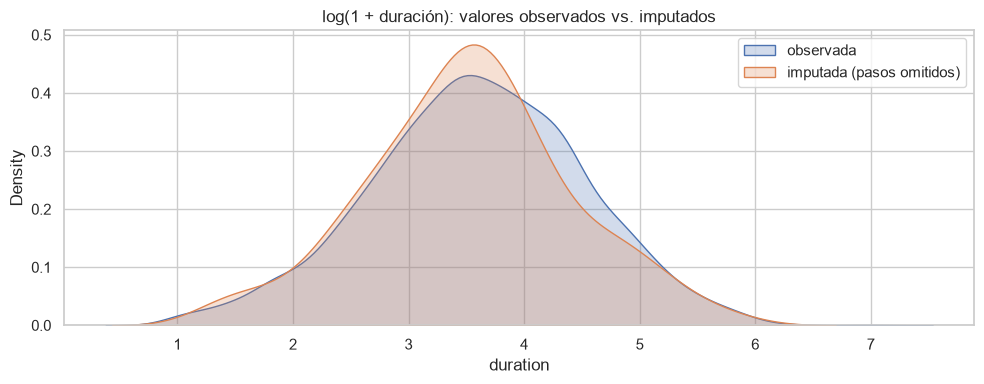

In [99]:
def fit_missing(train: pd.DataFrame) -> dict:
    t = train.loc[~train["is_skipped"]]
    return {"median_by_step": t.groupby("step_id")["duration"].median().to_dict(),
            "global_median": float(t["duration"].median())}

def apply_missing(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    d = df.copy()
    d["is_skipped"] = (d["start_time"] == -1) & (d["end_time"] == -1)
    for c in ["start_time", "end_time"]:
        d[c] = d[c].where(~d["is_skipped"], np.nan)
    d["duration"] = d["end_time"] - d["start_time"]
    fill = d["step_id"].map(params["median_by_step"]).fillna(params["global_median"])
    d["duration_imputed"] = d["duration"].fillna(fill)
    return d

miss_params = fit_missing(steps)
pp = apply_missing(steps, miss_params)
print("NaN en start/end después de convertir el centinela:", pp[["start_time", "end_time"]].isna().sum().to_dict())
print("NaN en duration_imputed:", pp["duration_imputed"].isna().sum())
print("Pasos imputados con mediana global (step_id sin referencia):",
      int(pp.loc[pp["is_skipped"], "step_id"].map(miss_params["median_by_step"]).isna().sum()))

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(np.log1p(pp.loc[~pp["is_skipped"], "duration"]), ax=ax, label="observada", fill=True)
sns.kdeplot(np.log1p(pp.loc[pp["is_skipped"], "duration_imputed"]), ax=ax, label="imputada (pasos omitidos)", fill=True)
ax.set_title("log(1 + duración): valores observados vs. imputados"); ax.legend()
plt.tight_layout(); plt.show()

### 8.2 Duplicados e inconsistencias

- **No hay filas duplicadas exactas.** Los `step_id` repetidos dentro de una grabación son **legítimos**: son ciclos que la receta pide repetir (calentar en microondas y revolver, en *Dressed Up Meatballs*; cortar porciones en *Pinwheels*). No se eliminan; se añade `repeat_idx` para distinguir la primera ejecución de las repeticiones.
- **Dos `step_id` (10 y 25) tienen dos descripciones distintas**, cada una con un solo caso discrepante. Se conserva el `step_id` como identidad del paso (la descripción no se usa como característica) y se registra como hallazgo de calidad de la anotación.
- **Discrepancias de `person_id` entre fuentes.** No hay forma de saber cuál fuente es la correcta con los datos disponibles. Se conserva el valor de las anotaciones de pasos (la fuente más detallada y la que usa el benchmark), se agrega la bandera `person_conflict` y se documenta para reportarlo a los autores. Como `person_id` no se usará como predictor (ver 8.4), el impacto es acotado.

In [100]:
def apply_consistency(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["repeat_idx"] = d.groupby(["recording_id", "step_id"]).cumcount()
    pm = video_info.set_index("recording_id")["person_id"]
    d["person_conflict"] = d["person_id"].astype(int) != d["recording_id"].map(pm)
    return d

pp = apply_consistency(pp)
print("Pasos que son repetición (repeat_idx > 0):", int((pp["repeat_idx"] > 0).sum()))
print("Grabaciones con conflicto de person_id:", pp.loc[pp["person_conflict"], "recording_id"].nunique())

Pasos que son repetición (repeat_idx > 0): 43
Grabaciones con conflicto de person_id: 7


### 8.3 Valores atípicos en la duración

**Diagnóstico.** La duración tiene una asimetría positiva fuerte. Se comparan dos criterios: la regla de Tukey (1.5 × IQR) sobre la escala original y sobre la escala logarítmica.

In [101]:
def iqr_bounds(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75]); iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

obs_dur = pp.loc[~pp["is_skipped"], "duration"]
lo, hi = iqr_bounds(obs_dur)
lo_l, hi_l = iqr_bounds(np.log1p(obs_dur))
out_raw = (obs_dur < lo) | (obs_dur > hi)
out_log = (np.log1p(obs_dur) < lo_l) | (np.log1p(obs_dur) > hi_l)
print(f"Escala original: límites [{lo:.1f}, {hi:.1f}] s -> {out_raw.sum()} atípicos ({100*out_raw.mean():.1f} %)")
print(f"Escala log:      límites [{np.expm1(lo_l):.1f}, {np.expm1(hi_l):.1f}] s -> {out_log.sum()} atípicos ({100*out_log.mean():.1f} %)")

ol = pp.loc[obs_dur.index[out_raw]]
print("\nVerbos más comunes entre los atípicos (escala original) vs. en todo el conjunto:")
comp = pd.DataFrame({"% en atípicos": ol["verb"].astype(str).value_counts(normalize=True).mul(100),
                     "% en todos": pp["verb"].astype(str).value_counts(normalize=True).mul(100)}).dropna()
display(comp.sort_values("% en atípicos", ascending=False).head(10))
print("Pasos más largos:")
display(pp.loc[~pp["is_skipped"]].nlargest(5, "duration")[["recording_id", "activity_name", "description", "duration", "has_errors"]])

Escala original: límites [-55.5, 142.6] s -> 194 atípicos (6.5 %)
Escala log:      límites [2.0, 453.6] s -> 18 atípicos (0.6 %)

Verbos más comunes entre los atípicos (escala original) vs. en todo el conjunto:


,% en atípicos,% en todos
verb,,
cook,20.103,4.307
microwave,18.041,4.275
chop,6.701,3.167
peel,6.701,2.882
mince,5.155,1.362
add,4.639,23.496
toast,4.124,0.317
cut,3.093,2.913
heat,3.093,1.900


Pasos más largos:


,recording_id,activity_name,description,duration,has_errors
1799,20_9,Sauted Mushrooms,Chop-Chop 1 shallot,"1,068.210",False
3077,29_7,Caprese Bruschetta,Toast-Toast both sides of the slices on the pa...,539.109,False
2444,25_1,Pan Fried Tofu,Cook-Cook 5 to 6 minutes until tofu cubes are ...,497.899,False
2143,22_10,Herb Omelet with Fried Tomatoes,cook-cook the tomatoes cut-side down until the...,430.503,False
655,7_2,Breakfast Burritos,"Microwave-Microwave for 3 minutes, stirring in...",406.541,False


In [102]:
# ¿Los atípicos se explican por la acción? Atípicos relativos a la mediana de su propio step_id
ratio = pp["duration"] / pp["step_id"].map(miss_params["median_by_step"])
print("Pasos que duran > 5x la mediana de su mismo step_id:", int((ratio > 5).sum()))
print("Tasa de error en esos pasos: {:.1f} % (global {:.1f} %)".format(
    100 * pp.loc[ratio > 5, "has_errors"].mean(), 100 * pp["has_errors"].mean()))

Pasos que duran > 5x la mediana de su mismo step_id: 14
Tasa de error en esos pasos: 7.1 % (global 28.9 %)


**Decisión y justificación.**

- **No se eliminan atípicos.** En escala original, las acciones intrínsecamente largas están muy sobrerrepresentadas entre los atípicos (*cook* y *microwave* son el 38 % de los atípicos frente al 8.6 % del total): son duraciones reales del proceso, no ruido. Eliminarlas sesgaría el SOP hacia acciones cortas.
- **Los atípicos *relativos* sí son sospechosos, pero no de error del operador.** Los 14 pasos que duran más de 5 veces la mediana de su mismo paso tienen una tasa de error de solo 7.1 % (contra 28.9 % global). Casos como "Chop 1 shallot" con 1,068 s, en una grabación con cobertura de 153 % y 5 solapamientos, apuntan a **límites de segmento mal anotados**. Se conservan, pero se marcan para revisión manual y quedan acotados por la winsorización.
- **Transformación logarítmica `log1p`.** Lleva la asimetría a prácticamente cero y reduce drásticamente la proporción de atípicos según IQR; es la transformación no lineal adecuada para tiempos, que son multiplicativos por naturaleza.
- **Winsorización en los percentiles 1 y 99 de entrenamiento** sobre la escala log, como protección adicional para modelos sensibles a extremos (regresión logística, redes). Los límites se guardan para aplicarlos a validación y prueba.
- **Característica relativa `dur_ratio_step`** (duración / mediana del mismo paso): separa "este paso es largo porque la acción es larga" de "este paso tardó anormalmente", que es lo relevante para detectar desviaciones.

Límites de winsorización (s): {'log_p01': 2.99, 'log_p99': 285.56}


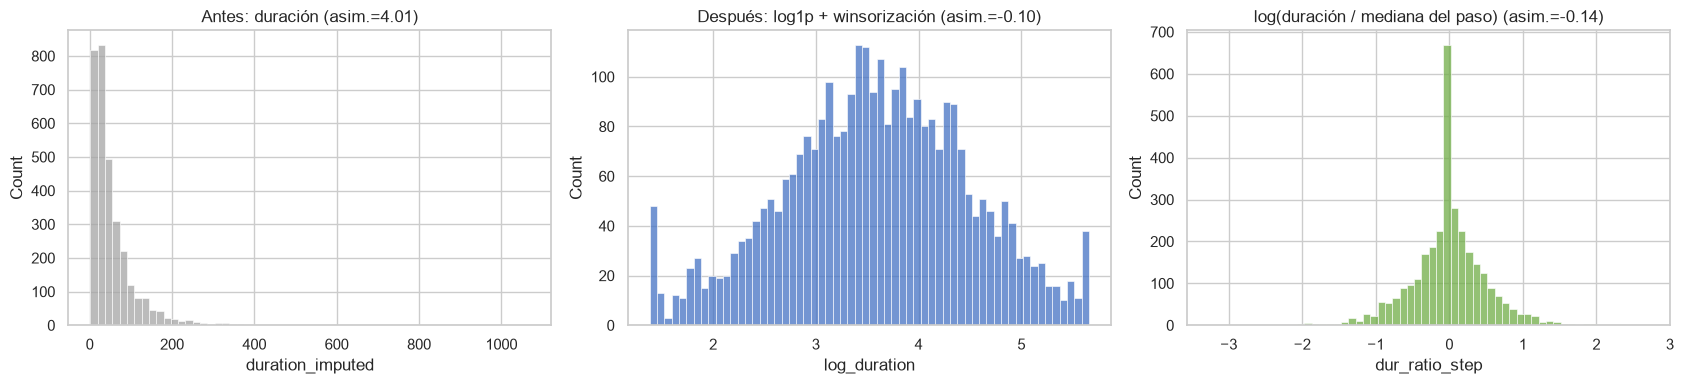

In [103]:
def fit_outliers(df: pd.DataFrame) -> dict:
    x = np.log1p(df.loc[~df["is_skipped"], "duration"])
    return {"log_p01": float(x.quantile(0.01)), "log_p99": float(x.quantile(0.99))}

def apply_outliers(df: pd.DataFrame, params: dict, miss: dict) -> pd.DataFrame:
    d = df.copy()
    d["log_duration"] = np.log1p(d["duration_imputed"]).clip(params["log_p01"], params["log_p99"])
    ref = d["step_id"].map(miss["median_by_step"]).fillna(miss["global_median"])
    d["dur_ratio_step"] = np.log(d["duration_imputed"] / ref)
    return d

out_params = fit_outliers(pp)
pp = apply_outliers(pp, out_params, miss_params)
print("Límites de winsorización (s):", {k: round(float(np.expm1(v)), 2) for k, v in out_params.items()})

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(pp["duration_imputed"], bins=60, ax=axes[0], color="#a5a5a5")
axes[0].set_title(f"Antes: duración (asim.={pp['duration_imputed'].skew():.2f})")
sns.histplot(pp["log_duration"], bins=60, ax=axes[1], color="#4472c4")
axes[1].set_title(f"Después: log1p + winsorización (asim.={pp['log_duration'].skew():.2f})")
sns.histplot(pp["dur_ratio_step"], bins=60, ax=axes[2], color="#70ad47")
axes[2].set_title(f"log(duración / mediana del paso) (asim.={pp['dur_ratio_step'].skew():.2f})")
plt.tight_layout(); plt.show()

### 8.4 Alta cardinalidad

**Diagnóstico.** `step_id` (≈350 clases) y `verb` (≈80 clases) tienen alta cardinalidad con colas largas: un *one-hot* produciría cientos de columnas dispersas, muchas con muy pocos ejemplos, lo que favorece el sobreajuste y contradice el objetivo 2.1.

**Decisiones y justificación.**

| Variable | Estrategia | Por qué |
|---|---|---|
| `verb` | Normalizar sinónimos y agrupar los verbos con menos de 30 pasos en entrenamiento en `"other"` | Conserva las acciones frecuentes y semánticamente distintas; las raras no tienen soporte estadístico suficiente. |
| `step_id` | **No** se codifica con *one-hot*; se reemplaza por **codificación por frecuencia** y por la característica `dur_ratio_step` | Su información útil (escala de tiempo esperada, qué tan común es) se conserva en pocas columnas numéricas. |
| `activity_name` | *One-hot* (24 niveles, todos con soporte suficiente) | Cardinalidad manejable. |
| `person_id`, `environment` | **Se excluyen como predictores** | Son identificadores del participante y de la cocina. Usarlos haría que el modelo memorice quién o dónde, y no generalizaría a los operadores ni a la planta del cliente. Se conservan para análisis de sesgo. |

verb: 84 clases -> verb_grouped: 19 clases
Pasos en 'other': 22.6 %
Verbos conservados: ['add', 'cook', 'cut', 'heat', 'melt', 'microwave', 'mix', 'peel', 'place', 'pour', 'remove', 'roll', 'scoop', 'season', 'sprinkle', 'take', 'top', 'transfer']


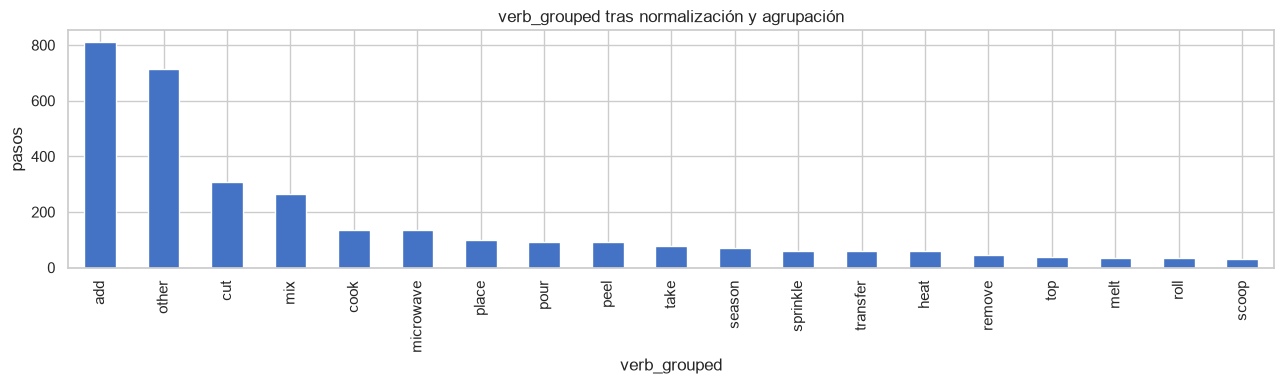

In [104]:
VERB_SYNONYMS = {"measure and add": "add", "cut or tear": "cut", "slice": "cut", "chop": "cut",
                 "dice": "cut", "mince": "cut", "stir": "mix", "whisk": "mix", "combine": "mix"}
MIN_VERB_COUNT = 30

def fit_cardinality(df: pd.DataFrame) -> dict:
    vb = df["verb"].astype(str).replace(VERB_SYNONYMS)
    counts = vb.value_counts()
    keep = sorted(counts[counts >= MIN_VERB_COUNT].index)
    step_freq = (df["step_id"].value_counts() / len(df)).to_dict()
    return {"keep_verbs": keep, "step_freq": step_freq}

def apply_cardinality(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    d = df.copy()
    vb = d["verb"].astype(str).replace(VERB_SYNONYMS)
    d["verb_grouped"] = np.where(vb.isin(params["keep_verbs"]), vb, "other")
    d["step_freq"] = d["step_id"].map(params["step_freq"]).fillna(0.0)
    return d

card_params = fit_cardinality(pp)
pp = apply_cardinality(pp, card_params)
print(f"verb: {pp['verb'].nunique()} clases -> verb_grouped: {pp['verb_grouped'].nunique()} clases")
print(f"Pasos en 'other': {100*(pp['verb_grouped']=='other').mean():.1f} %")
print("Verbos conservados:", card_params["keep_verbs"])

fig, ax = plt.subplots(figsize=(13, 4))
pp["verb_grouped"].value_counts().plot.bar(ax=ax, color="#4472c4")
ax.set_title("verb_grouped tras normalización y agrupación"); ax.set_ylabel("pasos")
plt.tight_layout(); plt.show()

### 8.5 Desbalanceo de clases

No se remuestrea en esta etapa (el remuestreo se aplica dentro del ciclo de entrenamiento y solo sobre entrenamiento, nunca antes de particionar), pero se cuantifica para fijar la estrategia de modelado.

In [105]:
pos = pp["has_errors"].mean()
print(f"has_errors: {100*pos:.1f} % positivos -> razón negativos:positivos = {(1-pos)/pos:.2f} : 1")
tags = pp[tag_cols].sum().sort_values()
print("\nCategorías de error (razón respecto a la mayoritaria):")
print((tags.max() / tags).round(1).rename(lambda c: c.replace("err_", "")).to_string())

# Pesos de clase balanceados (n / (k * n_c)) para usar en el modelado
n, k = len(pp), 2
w = {False: n / (k * (~pp["has_errors"]).sum()), True: n / (k * pp["has_errors"].sum())}
print("\nPesos de clase sugeridos para has_errors:", {str(a): round(b, 3) for a, b in w.items()})

has_errors: 28.9 % positivos -> razón negativos:positivos = 2.46 : 1

Categorías de error (razón respecto a la mayoritaria):
other               83.000
temperature_error    8.600
timing_error         3.000
measurement_error    1.600
missing_step         1.500
preparation_error    1.200
order_error          1.100
technique_error      1.000

Pesos de clase sugeridos para has_errors: {'False': np.float64(0.703), 'True': np.float64(1.731)}


**Estrategia para el modelado.** El desbalanceo del objetivo binario es **moderado**, así que basta con `class_weight="balanced"`, partición estratificada y métricas que no se dejan engañar por la clase mayoritaria (F1, *recall* de la clase con error y área bajo la curva precisión-*recall*). El problema serio está en las **categorías de error**: las más raras tienen muy pocos ejemplos. Para clasificar el *tipo* de error se recomienda agrupar las categorías minoritarias o tratarlas como un problema de pocos ejemplos, en línea con los métodos basados en algoritmos que revisan Huang y Dai (2021).

### 8.6 Pipeline completo aplicado a validación y prueba

Todas las transformaciones se encadenan con los parámetros ajustados en entrenamiento y se aplican sin recalcular nada sobre validación y prueba.

In [106]:
PARAMS = {"missing": miss_params, "outliers": out_params, "cardinality": card_params}

FEATURES_NUM = ["log_duration", "dur_ratio_step", "rel_position", "step_freq", "repeat_idx"]
FEATURES_BIN = ["is_skipped"]
FEATURES_CAT = ["activity_name", "verb_grouped"]
TARGET = "has_errors"

def preprocess(df_raw: pd.DataFrame, params: dict) -> pd.DataFrame:
    d = df_raw.copy()
    d = d.merge(meta[["recording_id", "video_duration_s"]], on="recording_id", how="left") \
        if "video_duration_s" not in d else d
    d = apply_missing(d, params["missing"])
    d = apply_consistency(d)
    d = apply_outliers(d, params["outliers"], params["missing"])
    d = apply_cardinality(d, params["cardinality"])
    d["rel_position"] = d["step_order"] / d.groupby("recording_id")["step_order"].transform("max")
    return d

processed = {name: preprocess(full_steps[full_steps["split"] == name].reset_index(drop=True), PARAMS)
             for name in ["train", "val", "test"]}

summary = pd.DataFrame({
    name: {"pasos": len(d), "grabaciones": d["recording_id"].nunique(),
           "NaN en características": int(d[FEATURES_NUM + FEATURES_BIN + FEATURES_CAT].isna().sum().sum()),
           "verbos fuera de vocabulario (→other)": f"{100*(d['verb_grouped']=='other').mean():.1f} %",
           "step_id no visto en train": int((d["step_freq"] == 0).sum())}
    for name, d in processed.items()}).T
summary

,pasos,grabaciones,NaN en características,verbos fuera de vocabulario (→other),step_id no visto en train
train,3158,213,0,22.6 %,0
val,929,62,0,21.2 %,0
test,1613,109,0,24.1 %,0


In [107]:
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)
cols_out = ["recording_id", "split", "step_order", "step_id", "start_time", "end_time"] + \
           FEATURES_NUM + FEATURES_BIN + FEATURES_CAT + [TARGET] + tag_cols
for name, d in processed.items():
    d[cols_out].to_csv(OUT_DIR / f"cc4d_steps_{name}.csv", index=False)
(OUT_DIR / "preprocessing_params.json").write_text(json.dumps(
    {k: {kk: (vv if not isinstance(vv, dict) else {str(a): b for a, b in vv.items()}) for kk, vv in v.items()}
     for k, v in PARAMS.items()}, indent=2, default=float))
print("Archivos generados (no se versionan; se regeneran ejecutando esta libreta):")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p}  {p.stat().st_size/1024:.0f} KB")

Archivos generados (no se versionan; se regeneran ejecutando esta libreta):
  data\processed\cc4d_steps_test.csv  264 KB
  data\processed\cc4d_steps_train.csv  517 KB
  data\processed\cc4d_steps_val.csv  151 KB
  data\processed\preprocessing_params.json  24 KB


## 9. Relevancia preliminar de características (objetivo 2.1)

Antes de modelar, se estima cuánta información aporta cada característica preprocesada sobre `has_errors` usando **información mutua** (método de filtro que, a diferencia de la correlación, captura relaciones no lineales y funciona igual con numéricas y categóricas codificadas). También se revisa la redundancia entre numéricas: dos variables muy correlacionadas aportan casi la misma información.

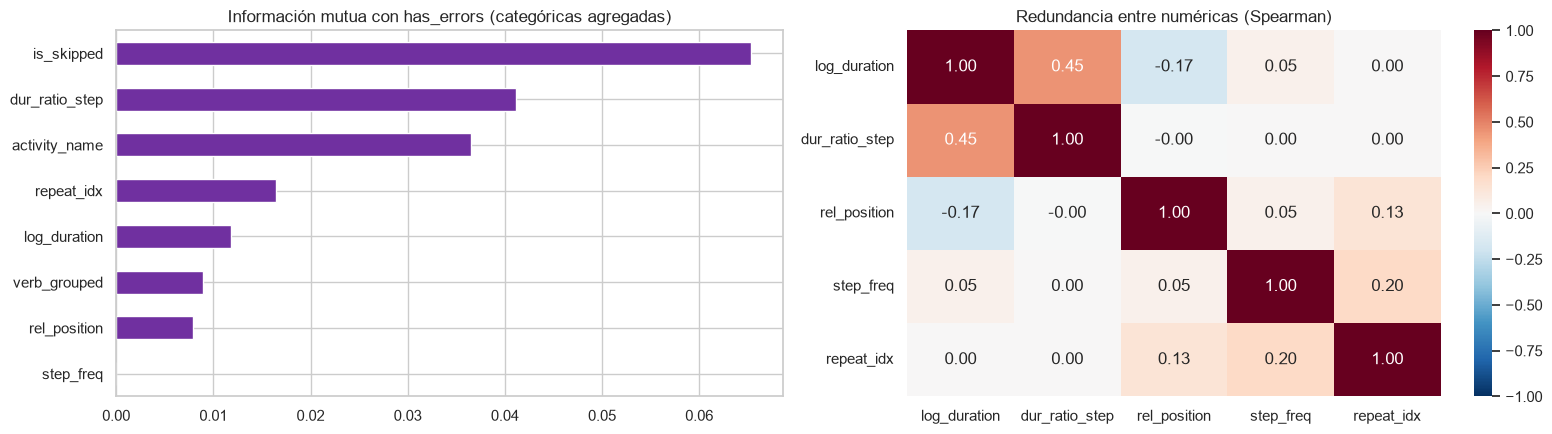

Características finales: 49 columnas (frente a 476 si se hiciera one-hot de todas las categóricas originales)


,información_mutua
is_skipped,0.065
dur_ratio_step,0.041
activity_name,0.036
repeat_idx,0.016
log_duration,0.012
verb_grouped,0.009
rel_position,0.008
step_freq,0.000


In [108]:
tr_p = processed["train"]
X = pd.concat([tr_p[FEATURES_NUM + FEATURES_BIN].astype(float),
               pd.get_dummies(tr_p[FEATURES_CAT], dtype=float)], axis=1)
y = tr_p[TARGET].astype(int)
discrete = [c not in FEATURES_NUM for c in X.columns]
mi = pd.Series(mutual_info_classif(X, y, discrete_features=discrete, random_state=SEED), index=X.columns)

# Agregar la información mutua de los dummies de cada variable categórica para compararlas como bloque
mi_group = mi.groupby(lambda c: next((f for f in FEATURES_CAT if c.startswith(f + "_")), c)).sum().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
mi_group.plot.barh(ax=axes[0], color="#7030a0")
axes[0].set_title("Información mutua con has_errors (categóricas agregadas)")
sns.heatmap(tr_p[FEATURES_NUM].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Redundancia entre numéricas (Spearman)")
plt.tight_layout(); plt.show()
print("Características finales:", X.shape[1], "columnas (frente a",
      steps["step_id"].nunique() + steps["verb"].nunique() + 24 + 8 + 10, "si se hiciera one-hot de todas las categóricas originales)")
mi_group.sort_values(ascending=False).to_frame("información_mutua")

**Observaciones sobre relevancia de características.**

- El preprocesamiento reduce el espacio de **476 columnas potenciales** (one-hot de todas las categóricas originales) a **49**, en línea con el objetivo 2.1.
- `is_skipped` es la característica con más información mutua, pero hay que leerla con cuidado: **un paso omitido es por definición un error *Missing Step***. Usarla para predecir `has_errors` en general sería una fuga de etiqueta; solo es válida para detectar los *otros* tipos de error, o como señal de que la percepción no encontró el paso.
- `dur_ratio_step` (duración relativa a su paso) aporta **más del triple de información** que la duración en escala log, lo que confirma la decisión de la sección 8.3.
- `step_freq` aporta información prácticamente nula: es **candidata a eliminarse** en la siguiente iteración de selección.
- Las numéricas finales tienen baja redundancia entre sí (|ρ| ≤ 0.45), así que ninguna duplica a otra.

## 10. Conclusiones

### Respuestas a las preguntas guía

**1. ¿Hay valores faltantes? ¿Hay patrones de ausencia?**
Sí, aunque ocultos: no hay `NaN` explícitos, pero 171 pasos (5.4 %) tienen tiempos codificados como −1. La ausencia **no es aleatoria**: el 98 % corresponde a pasos que el participante no ejecutó (error *Missing Step*) y el resto a un paso opcional. Varía significativamente por receta y entorno, pero no por persona. Se tratan con indicador `is_skipped`, conversión a `NaN` y, solo para la característica numérica de duración, imputación con la mediana del mismo paso.

**2. ¿Cuáles son las estadísticas resumidas?**
3,158 pasos en 213 grabaciones de entrenamiento, 24 recetas, 8 personas y 10 entornos. Un paso dura en mediana 33 s (rango intercuartílico 16-65 s); una grabación dura en mediana 13 minutos y tiene 14 pasos.

**3. ¿Hay valores atípicos?**
Sí: 6.5 % de los pasos según IQR en escala original, pero solo 0.6 % en escala logarítmica. La mayoría son acciones intrínsecamente largas (*cook*, *microwave*), y por eso se conservan. Los atípicos relativos a su propio paso (14 casos) parecen límites de anotación mal colocados, no errores del operador, y se marcan para revisión.

**4. ¿Cuál es la cardinalidad de las variables categóricas?**
Alta en `step_id` (350) y `verb` (84), baja en receta (24), entorno (10) y persona (8). `verb` se normalizó y agrupó a 19 clases; `step_id` se sustituyó por características numéricas en lugar de *one-hot*.

**5. ¿Hay distribuciones sesgadas? ¿Se necesita una transformación no lineal?**
Sí. La duración del paso tiene asimetría 4.0 y sigue aproximadamente una distribución log-normal; `log1p` la lleva a −0.1. También son asimétricas la duración del video, el tiempo muerto y el número de errores por grabación.

**6. ¿Hay tendencias temporales?**
Dentro de cada procedimiento, sí. La tasa de error baja de ≈28 % en la primera mitad a 18 % al final. Los errores de orden se concentran en la parte media, los de medición al inicio y los de *timing* en la parte media-final.

**7. ¿Hay correlación entre variables dependientes e independientes?**
La duración absoluta no se relaciona con el error, pero la duración relativa a su paso sí aporta información. Los pasos con error ocurren antes en la secuencia. A nivel grabación, los videos con error son más cortos y tienen menos tiempo muerto. Entre las predictoras se detectaron pares redundantes (ρ > 0.95) que deben reducirse a una sola variable.

**8. ¿Cómo se distribuyen los datos según las categorías?**
La tasa de error varía mucho entre recetas (de 5 % a 51 %) y el tipo de error dominante también. La asociación con el entorno es un artefacto del diseño de recolección; por eso entorno y persona se excluyen como predictores.

**9. ¿Se deberían normalizar las imágenes?**
No aplica en este avance: se analizaron las anotaciones, no los fotogramas. En la Semana 3, los fotogramas se normalizarán con el preprocesamiento propio de V-JEPA 2 (tamaño de entrada y media y desviación de su entrenamiento), no con una normalización ad hoc.

**10. ¿Hay desequilibrio de clases en la variable objetivo?**
Moderado en `has_errors` (71 / 29) y casi balanceado a nivel grabación (58 / 42). En las categorías de error es severo (hasta 83:1). Estrategia: `class_weight="balanced"`, partición estratificada, métricas F1 y AUC-PR, y agrupación de categorías raras.

### Implicaciones para el proyecto Video-to-SOP

- **El SOP debe modelarse como grafo, no como lista.** 121 de 213 grabaciones tienen pasos simultáneos, y la frecuencia de errores de orden cambia radicalmente entre recetas. El grafo de orden parcial del brief es necesario, no solo deseable.
- **Variación legítima frente a error.** El caso del paso opcional omitido sin error muestra que la anotación ya distingue ambos casos; la consolidación multi-video debe preservar esa distinción.
- **Calidad de la verdad de referencia.** Se detectaron inconsistencias de `person_id`, descripciones duplicadas para un mismo paso y límites de segmento sospechosos. Como el sistema se medirá contra estas anotaciones, conviene documentarlas y excluir o corregir los casos dudosos antes de calcular métricas.
- **Generalización a la planta del cliente.** Excluir persona y entorno como predictores evita que el modelo memorice condiciones de grabación que no existirán en producción.

### Siguientes pasos

1. Eliminar las características redundantes o sin información (`step_freq`) y repetir la selección con métodos de envoltura y embebidos.
2. Construir las características de percepción (embeddings de V-JEPA 2 por segmento) y evaluar reducción de dimensionalidad con PCA.
3. Revisar manualmente los 14 segmentos con duración relativa extrema y registrar las correcciones.
4. Replicar este EDA sobre EgoProceL para la parte multi-video.

## Referencias

- Bergsma, W. (2013). A bias-correction for Cramér's V and Tschuprow's T. *Journal of the Korean Statistical Society, 42*(3), 323–328.
- Brownlee, J. (2020, 20 de agosto). How to choose a feature selection method for machine learning. *Machine Learning Mastery.*
- Costa, R. (2022). *The CRISP-ML methodology: A step-by-step approach to real-world machine learning projects.* Edición propia.
- Galli, S. (2022). *Python feature engineering cookbook* (2.ª ed.). Packt Publishing.
- Huang, C. Y., y Dai, H. L. (2021). Learning from class-imbalanced data: Review of data driven methods and algorithm driven methods. *Data Science in Finance and Economics, 1*(1), 26–36.
- Kumar Mukhiya, S., y Ahmed, U. (2020). *Hands-on exploratory data analysis with Python.* Packt Publishing.
- Peddi, R., et al. (2024). CaptainCook4D: A dataset for understanding errors in procedural activities. *NeurIPS 2024 Datasets and Benchmarks Track.* https://arxiv.org/abs/2312.14556
- Studer, S., Bui, T. B., Drescher, C., Hanuschkin, A., Winkler, L., Peters, S., y Müller, K.-R. (2021). Towards CRISP-ML(Q): A machine learning process model with quality assurance methodology. *Machine Learning and Knowledge Extraction, 3*(2), 392–413.
- Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., y Plöd, M. (2023). *CRISP-ML(Q). The ML lifecycle process.* MLOps. INNOQ. https://ml-ops.org/content/crisp-ml